# 02 探索分析

| | 內容 |
|---|---|
| 輸入 | `data/processed/`（01 的輸出） |
| 輸出 | `output/figures/` |

重點：每日 6 目標的分布、觀測與預報的誤差、預報缺失、9–10 月負載型態、尖峰時刻分布。

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "config").is_dir():   # 找到專案根目錄（notebook 可從任何位置執行）
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import os
import polars as pl
from src.logging_setup import setup_logging

os.chdir(ROOT)
setup_logging(stage="notebook_02", level="WARNING")
pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(60)

polars.config.Config

In [2]:
import datetime as dt

import matplotlib.pyplot as plt
from IPython.display import Image, display

from config import paths, settings
from src.evaluation import timing_plots
from src.features import accuweather as accuweather_features
from src.features import targets

timing_plots.use_cjk_font()
daily = pl.read_parquet(paths.TARGETS_FILE)
clean = pl.read_parquet(paths.CLEAN_LOAD_FILE)
observed = pl.read_parquet(paths.PROCESSED_DIR / "weather_observed_daily.parquet")
forecast = pl.read_parquet(paths.PROCESSED_DIR / "weather_forecast_daily.parquet")
print(daily.shape, clean.shape, observed.shape, forecast.shape)

(1004, 27) (144576, 4) (1004, 21) (1001, 21)


## 1. 每日 6 目標

計分只看 6 個推導量：日／夜尖峰負載與時刻、全日最大爬升與下降。

In [3]:
summary = targets.summarize_targets(daily)
for name, table in summary.items():
    print(f"【{name}】")
    display(table)

【describe】


daytype,n,p_day_median,p_day_p10,p_day_p90,t_day_median,t_day_p10,t_day_p90,p_night_median,p_night_p10,p_night_p90,t_night_median,t_night_p10,t_night_p90,ramp_up_median,ramp_up_p10,ramp_up_p90,ramp_down_median,ramp_down_p10,ramp_down_p90
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""平日""",718,33579.43,29161.12,39860.66,840.0,680.0,990.0,31847.665,29049.38,36696.64,1060.0,1030.0,1100.0,1171.57,855.36,1538.75,705.975,553.7,919.27
"""週六""",143,30172.28,26562.6,35134.78,900.0,810.0,1020.0,29691.35,27225.03,34031.29,1090.0,1030.0,1150.0,620.56,466.54,826.86,511.37,420.4,673.03
"""週日""",143,28568.61,25401.04,33089.98,1010.0,820.0,1020.0,29224.97,26637.75,33420.22,1210.0,1090.0,1250.0,554.32,404.97,745.04,492.54,404.54,631.34


【censoring】


daytype,n,t_day_at_lower,t_day_at_upper,t_night_at_lower,t_night_at_upper
str,u32,f64,f64,f64,f64
"""平日""",718,0.011142,0.02507,0.417827,0.009749
"""週六""",143,0.0,0.146853,0.111888,0.006993
"""週日""",143,0.0,0.41958,0.0,0.090909


【contamination】


n_days,n_days_with_imputed,n_ramp_up_contaminated,n_ramp_down_contaminated,ramp_up_contamination_rate,ramp_down_contamination_rate
u32,u32,u32,u32,f64,f64
1004,3,0,0,0.0,0.0


## 2. 觀測 vs 預報

五站合併、重疊期逐項比較。溫度相關 0.92–0.96；**UV 兩者定義不同**（CODiS 為連續的累積量、
Accuweather 為整數 0–13 的最大 UV 指數），相關只有約 0.43。
時刻模型用的是五站白天最高溫的最大值（最後一列）。

In [4]:
accuweather_features.compare_with_observed(forecast, observed)

項目,n,r,bias,MAE
str,i64,f64,f64,f64
"""day_tmax""",4990,0.920727,0.958056,1.742184
"""day_tmin""",4990,0.955166,0.675551,1.378677
"""night_tmax""",4990,0.936706,0.573407,1.400741
"""night_tmin""",4990,0.936367,0.000581,1.454689
"""五站 day_tmax 最大值""",998,0.922893,1.157014,1.630561


## 3. 預報缺失

負載資料期間內，Accuweather 五站缺整日的日子（這些日子由插補處理，會在 log 警告）。

In [5]:
load_days = set(daily["date"].to_list())
missing = sorted(load_days - set(forecast["date"].to_list()))
from src.data import windy as windy_data

windy = windy_data.load_hourly().with_columns(pl.col("forecast_time").dt.date().alias("date"))
windy_missing = sorted(load_days - set(windy["date"].to_list()))
print("Accuweather 缺整日：", len(missing), missing)
print("Windy 缺整日：", len(windy_missing), windy_missing[:15], "…" if len(windy_missing) > 15 else "")

2026-10-01 15:50:02 | WARNING  | src.data.checks | Windy：完全重複 122 列，已刪除


Accuweather 缺整日： 6 [datetime.date(2024, 2, 24), datetime.date(2024, 2, 25), datetime.date(2024, 6, 9), datetime.date(2024, 6, 10), datetime.date(2025, 5, 3), datetime.date(2025, 5, 4)]
Windy 缺整日： 27 [datetime.date(2024, 2, 24), datetime.date(2024, 2, 25), datetime.date(2024, 2, 26), datetime.date(2024, 6, 9), datetime.date(2024, 6, 10), datetime.date(2024, 7, 28), datetime.date(2024, 7, 29), datetime.date(2024, 12, 1), datetime.date(2024, 12, 2), datetime.date(2025, 2, 23), datetime.date(2025, 2, 24), datetime.date(2025, 2, 25), datetime.date(2025, 2, 26), datetime.date(2025, 2, 27), datetime.date(2025, 2, 28)] …


In [6]:
print("Accuweather 日彙總涵蓋：", forecast["date"].min(), "~", forecast["date"].max(), "共", forecast.height, "天")

Accuweather 日彙總涵蓋： 2024-01-01 ~ 2026-10-03 共 1001 天


## 4. 9–10 月負載型態

提交日 10/1（四）、10/2（五）、10/3（六）。下圖是 9/20–10/10 各日別的平均日內曲線，
比較 2024 與 2025 年。

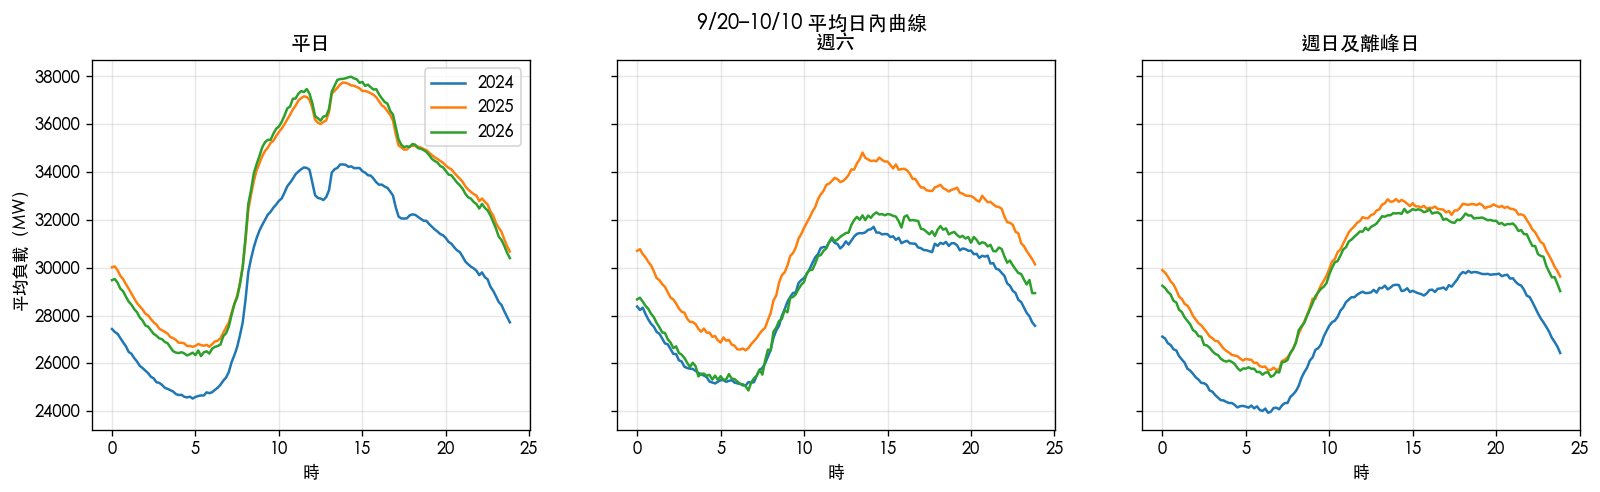

In [7]:
window = clean.with_columns(pl.col("ts").dt.date().alias("date")).join(
    daily.select("date", "price_daytype"), on="date"
).filter(
    (pl.col("date").dt.month().cast(pl.Int32) * 100 + pl.col("date").dt.day().cast(pl.Int32))
    .is_between(920, 1010)
).with_columns(
    pl.col("date").dt.year().alias("year"),
    (pl.col("ts").dt.hour().cast(pl.Int32) * 60 + pl.col("ts").dt.minute().cast(pl.Int32)).alias("minute"),
)
curves = window.group_by("year", "price_daytype", "minute").agg(pl.col("Load_MW").mean()).sort("minute")

figure, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for axis, daytype in zip(axes, ["平日", "週六", "週日及離峰日"]):
    for year in sorted(curves["year"].unique()):
        part = curves.filter((pl.col("year") == year) & (pl.col("price_daytype") == daytype))
        axis.plot(part["minute"] / 60, part["Load_MW"], label=str(year))
    axis.set_title(daytype); axis.set_xlabel("時"); axis.grid(alpha=0.3)
axes[0].set_ylabel("平均負載（MW）"); axes[0].legend()
figure.suptitle("9/20–10/10 平均日內曲線")
paths.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
figure.savefig(paths.FIGURES_DIR / "02_sep_oct_profiles.png", dpi=120, bbox_inches="tight")
plt.close(figure)
display(Image(filename=str(paths.FIGURES_DIR / "02_sep_oct_profiles.png"), width=1100))

In [8]:
window.group_by("year", "price_daytype").agg(pl.col("date").n_unique().alias("天數")).sort("year", "price_daytype")

year,price_daytype,天數
i32,str,u32
2024,"""平日""",14
2024,"""週六""",3
2024,"""週日及離峰日""",4
2025,"""平日""",13
2025,"""週六""",3
2025,"""週日及離峰日""",5
2026,"""平日""",6
2026,"""週六""",1
2026,"""週日及離峰日""",4


## 5. 尖峰時刻分布（12 張）

分四組（整體／平日／週六／週日及離峰日）× 三種圖（邊際分布、逐月、日夜聯合）。
夜尖峰窗口是 **17:10–21:00**，格點一律由 `night_peak_grid()` 產生，不手寫。

已輸出：timing_marginal_all.png


已輸出：timing_month_all.png


已輸出：timing_joint_all.png
已輸出：timing_marginal_weekday.png


已輸出：timing_month_weekday.png


已輸出：timing_joint_weekday.png
已輸出：timing_marginal_saturday.png


已輸出：timing_month_saturday.png


已輸出：timing_joint_saturday.png


已輸出：timing_marginal_offpeak.png


已輸出：timing_month_offpeak.png


已輸出：timing_joint_offpeak.png


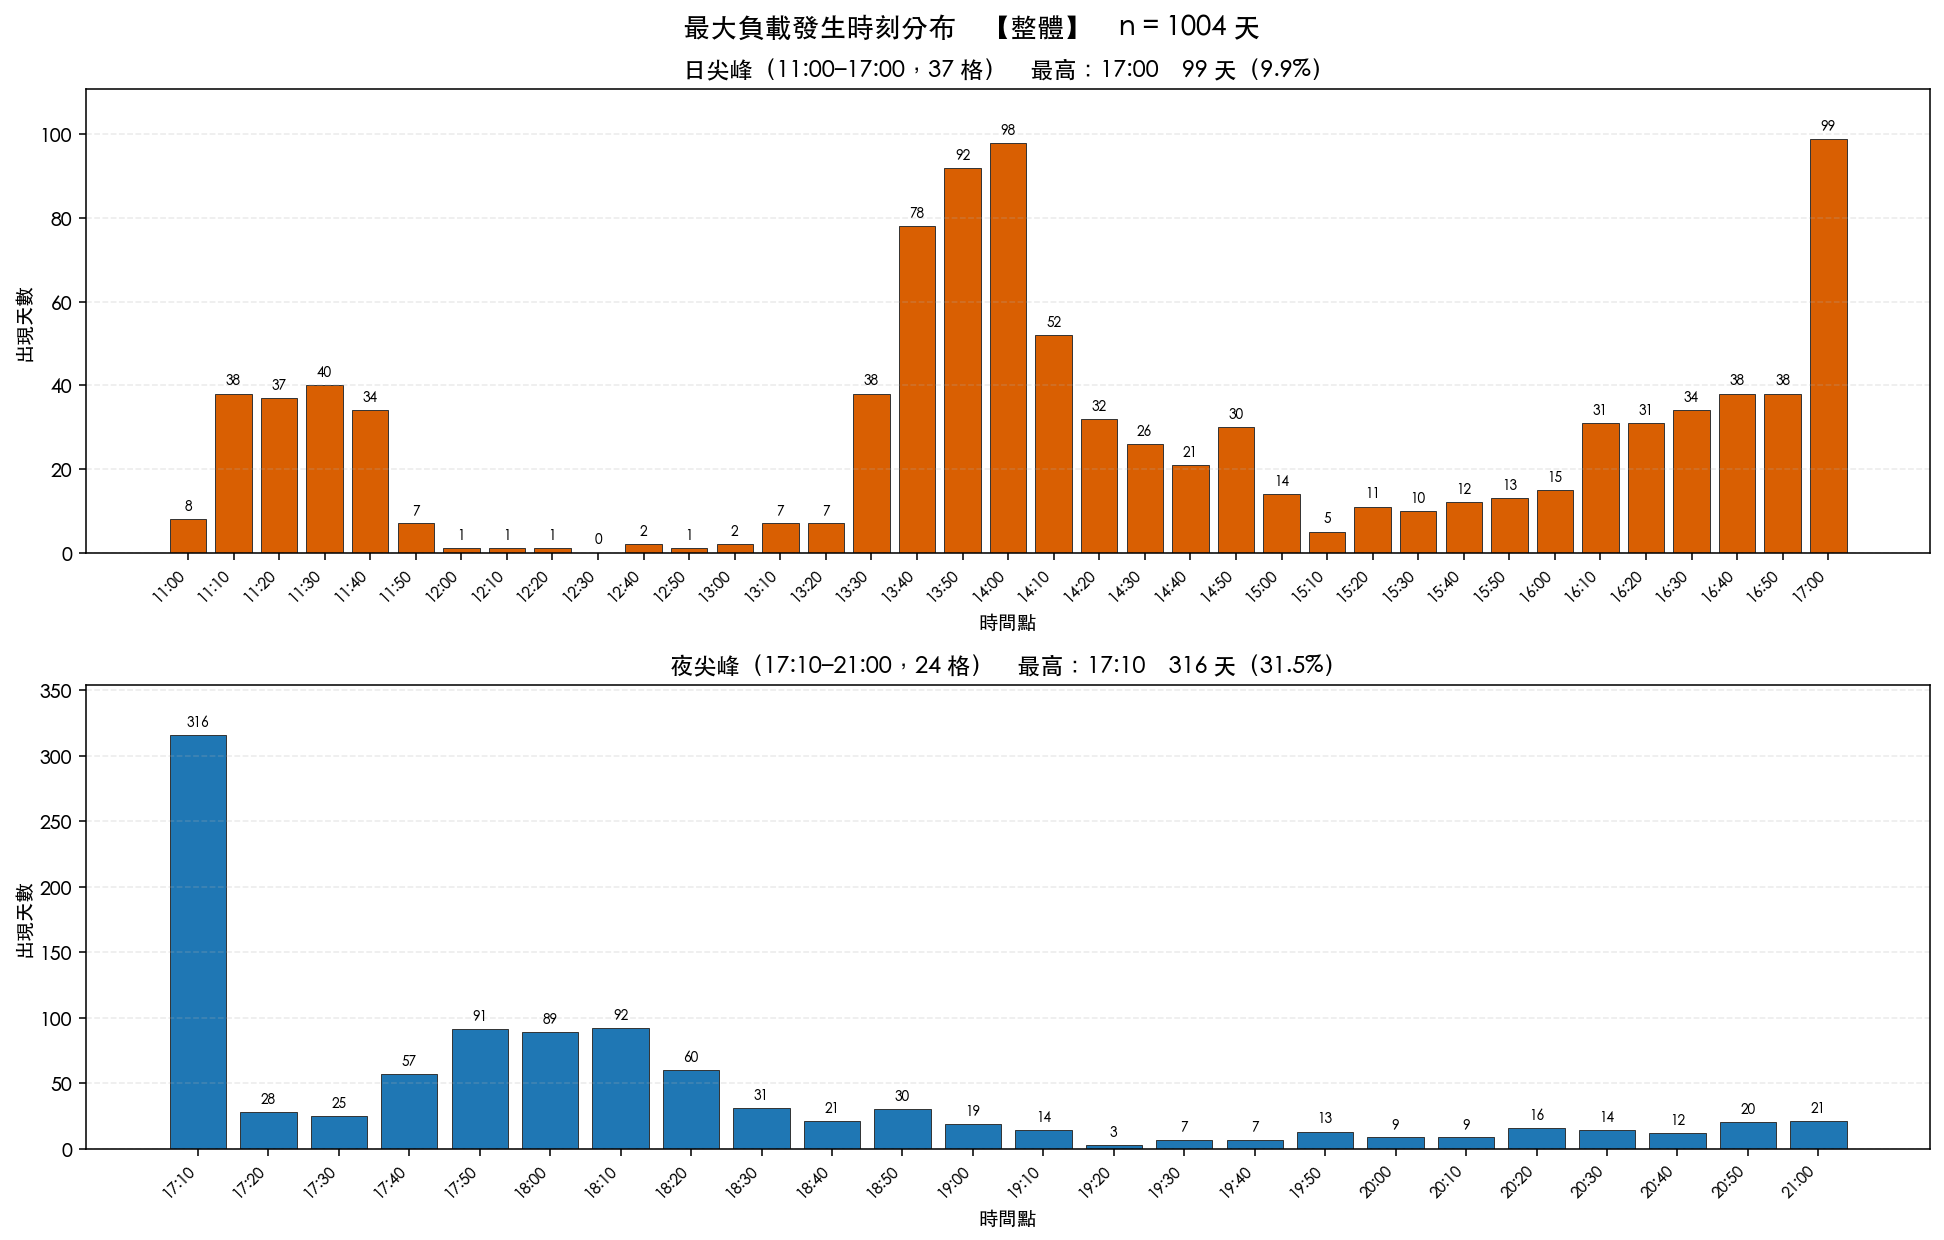

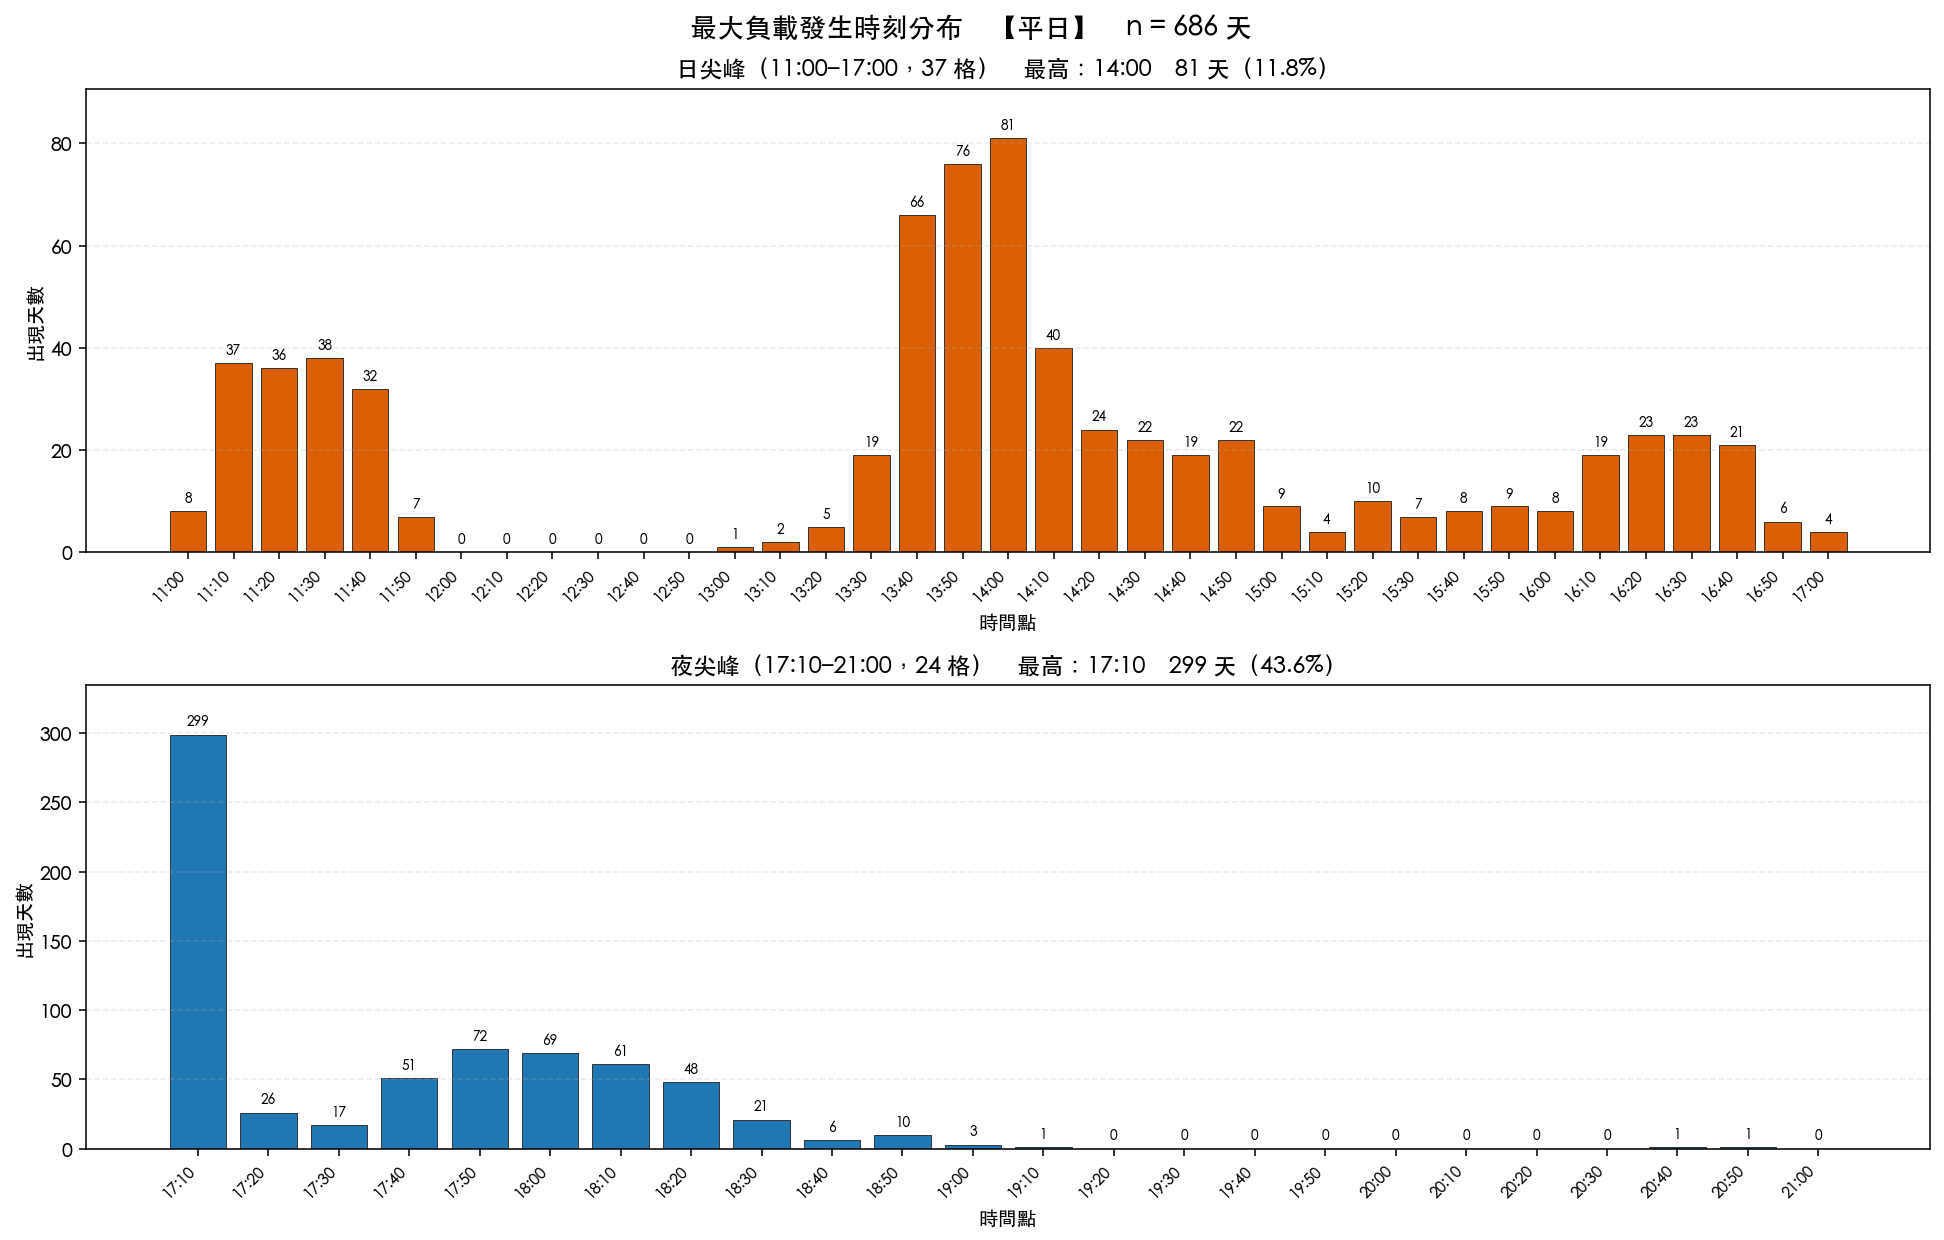

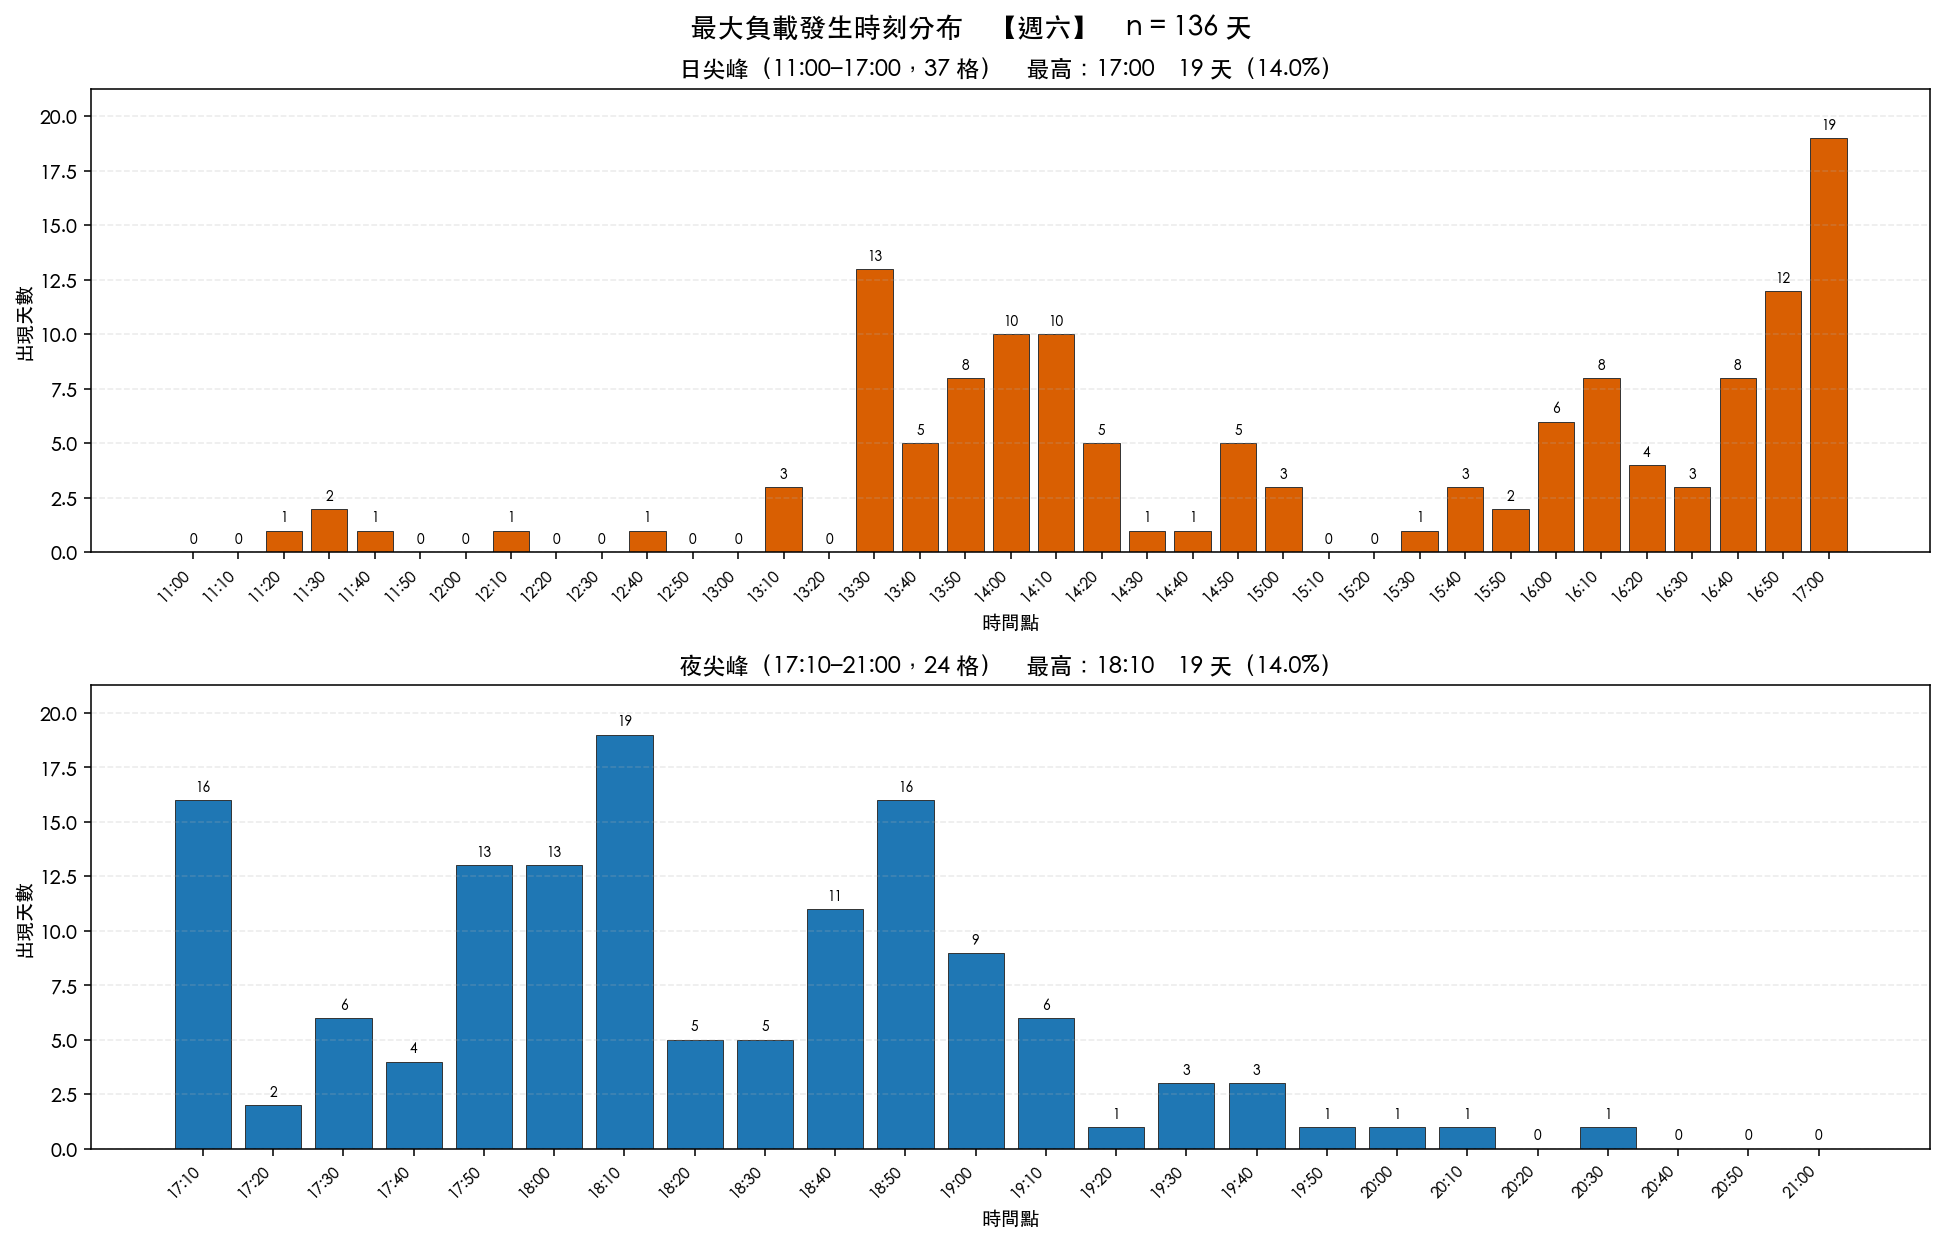

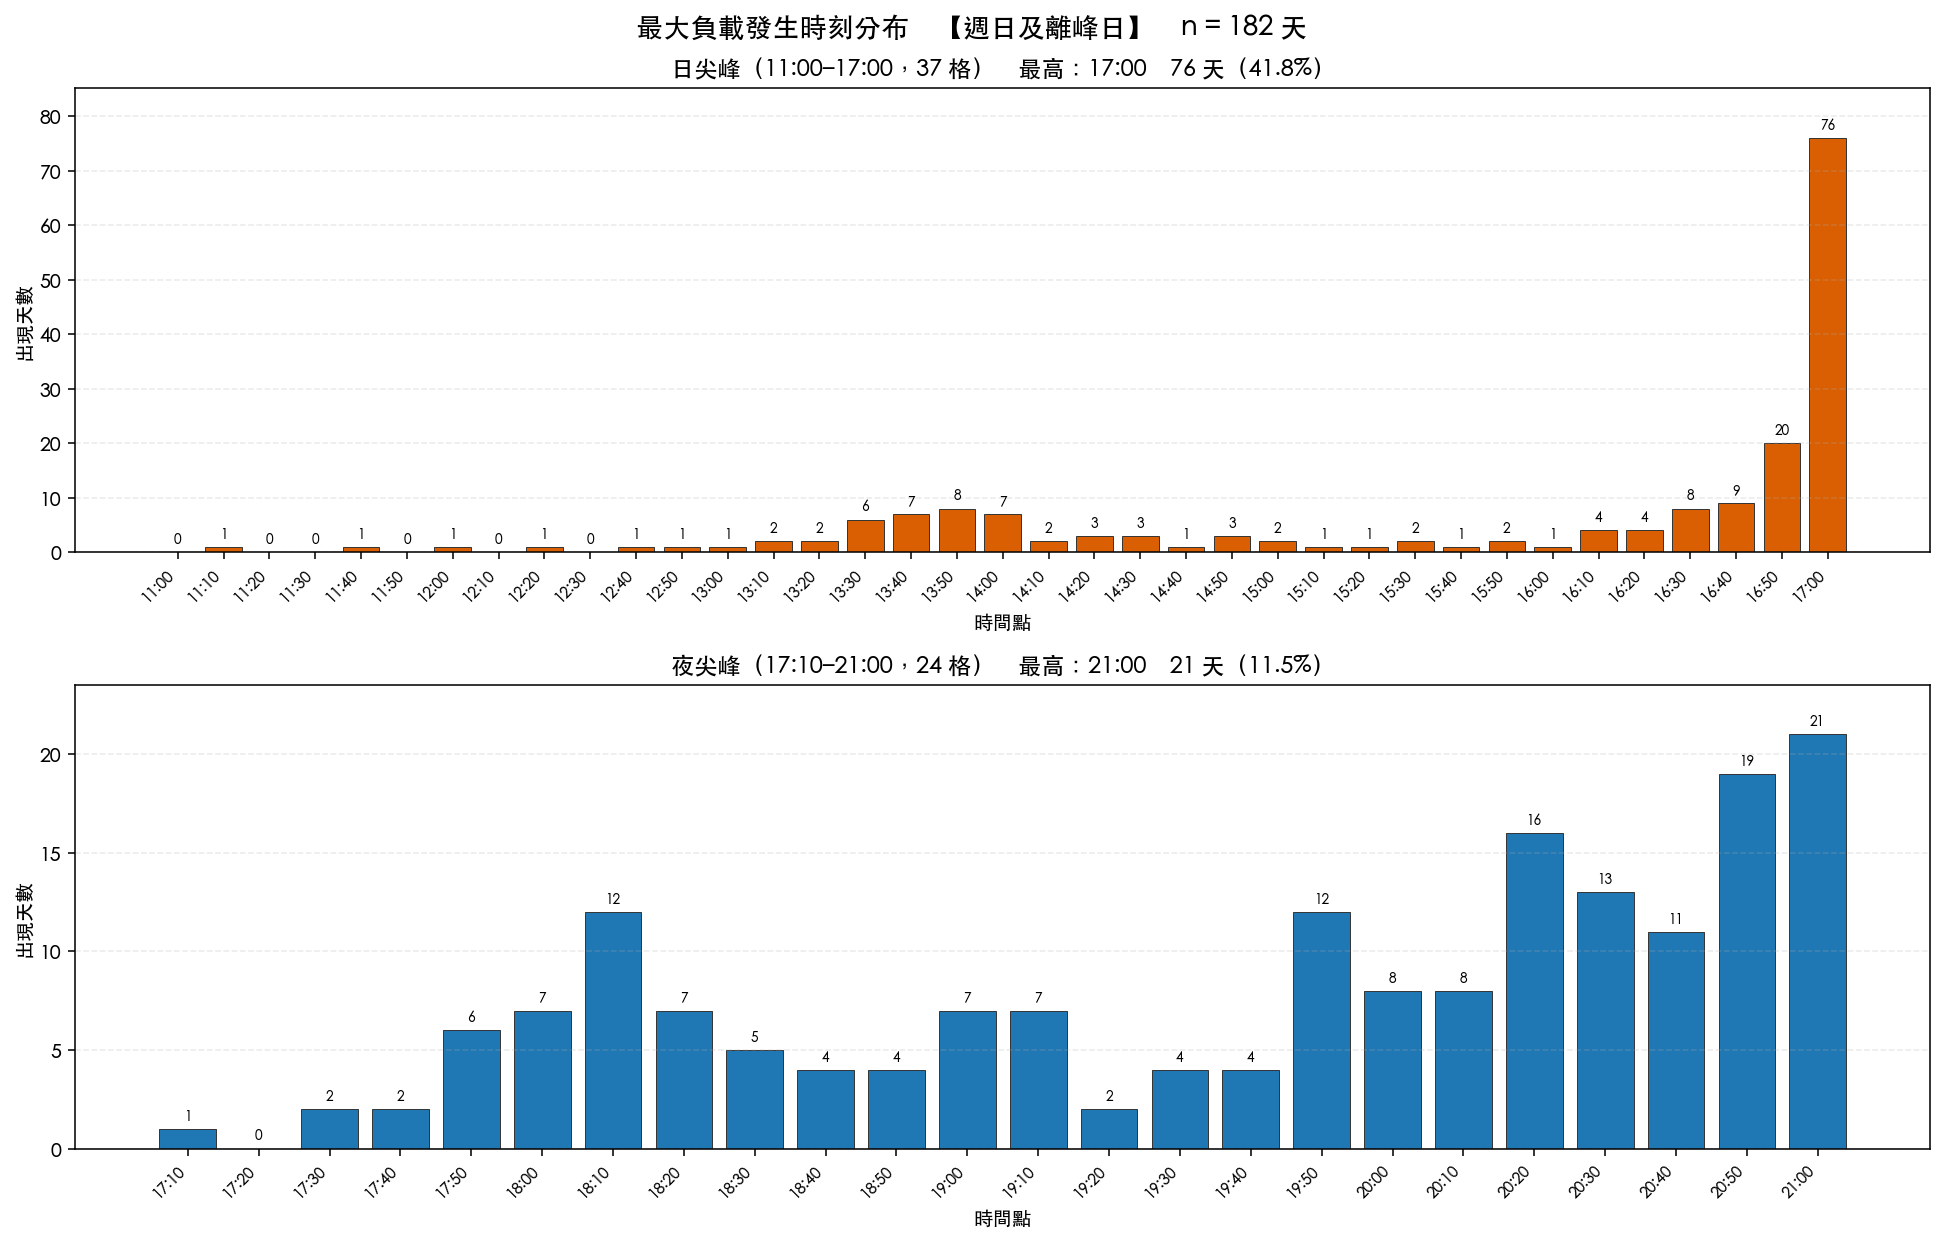

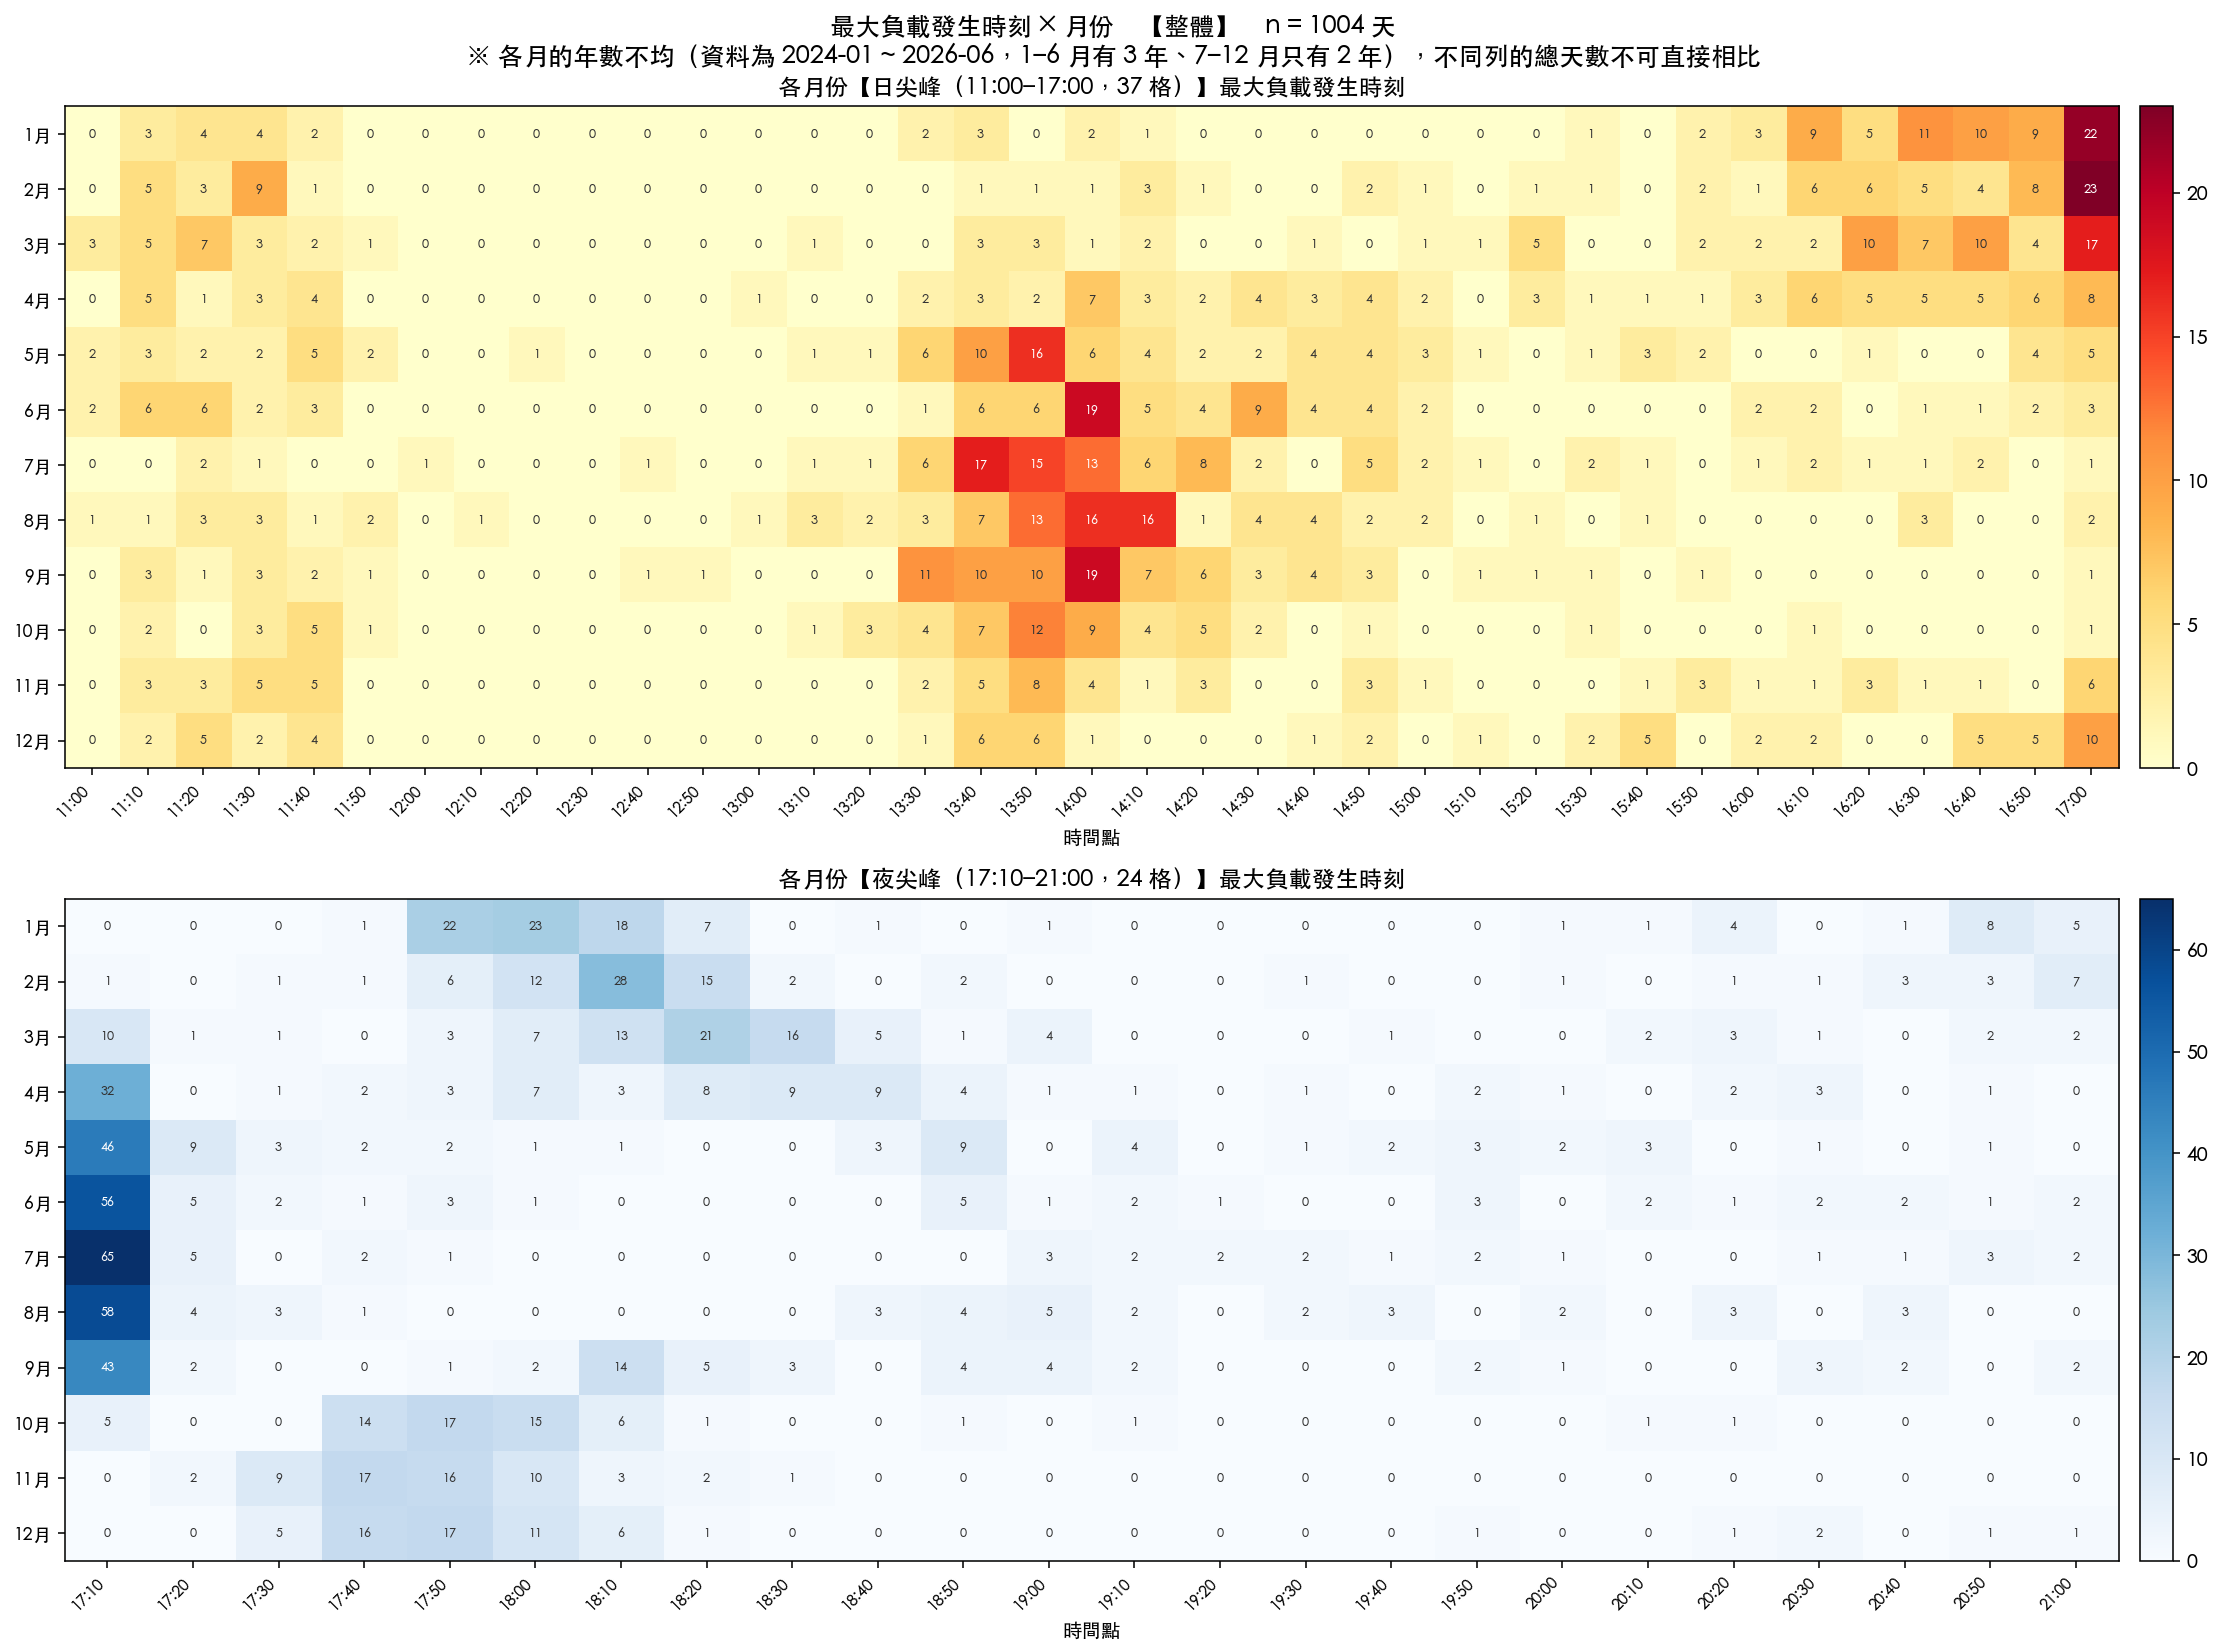

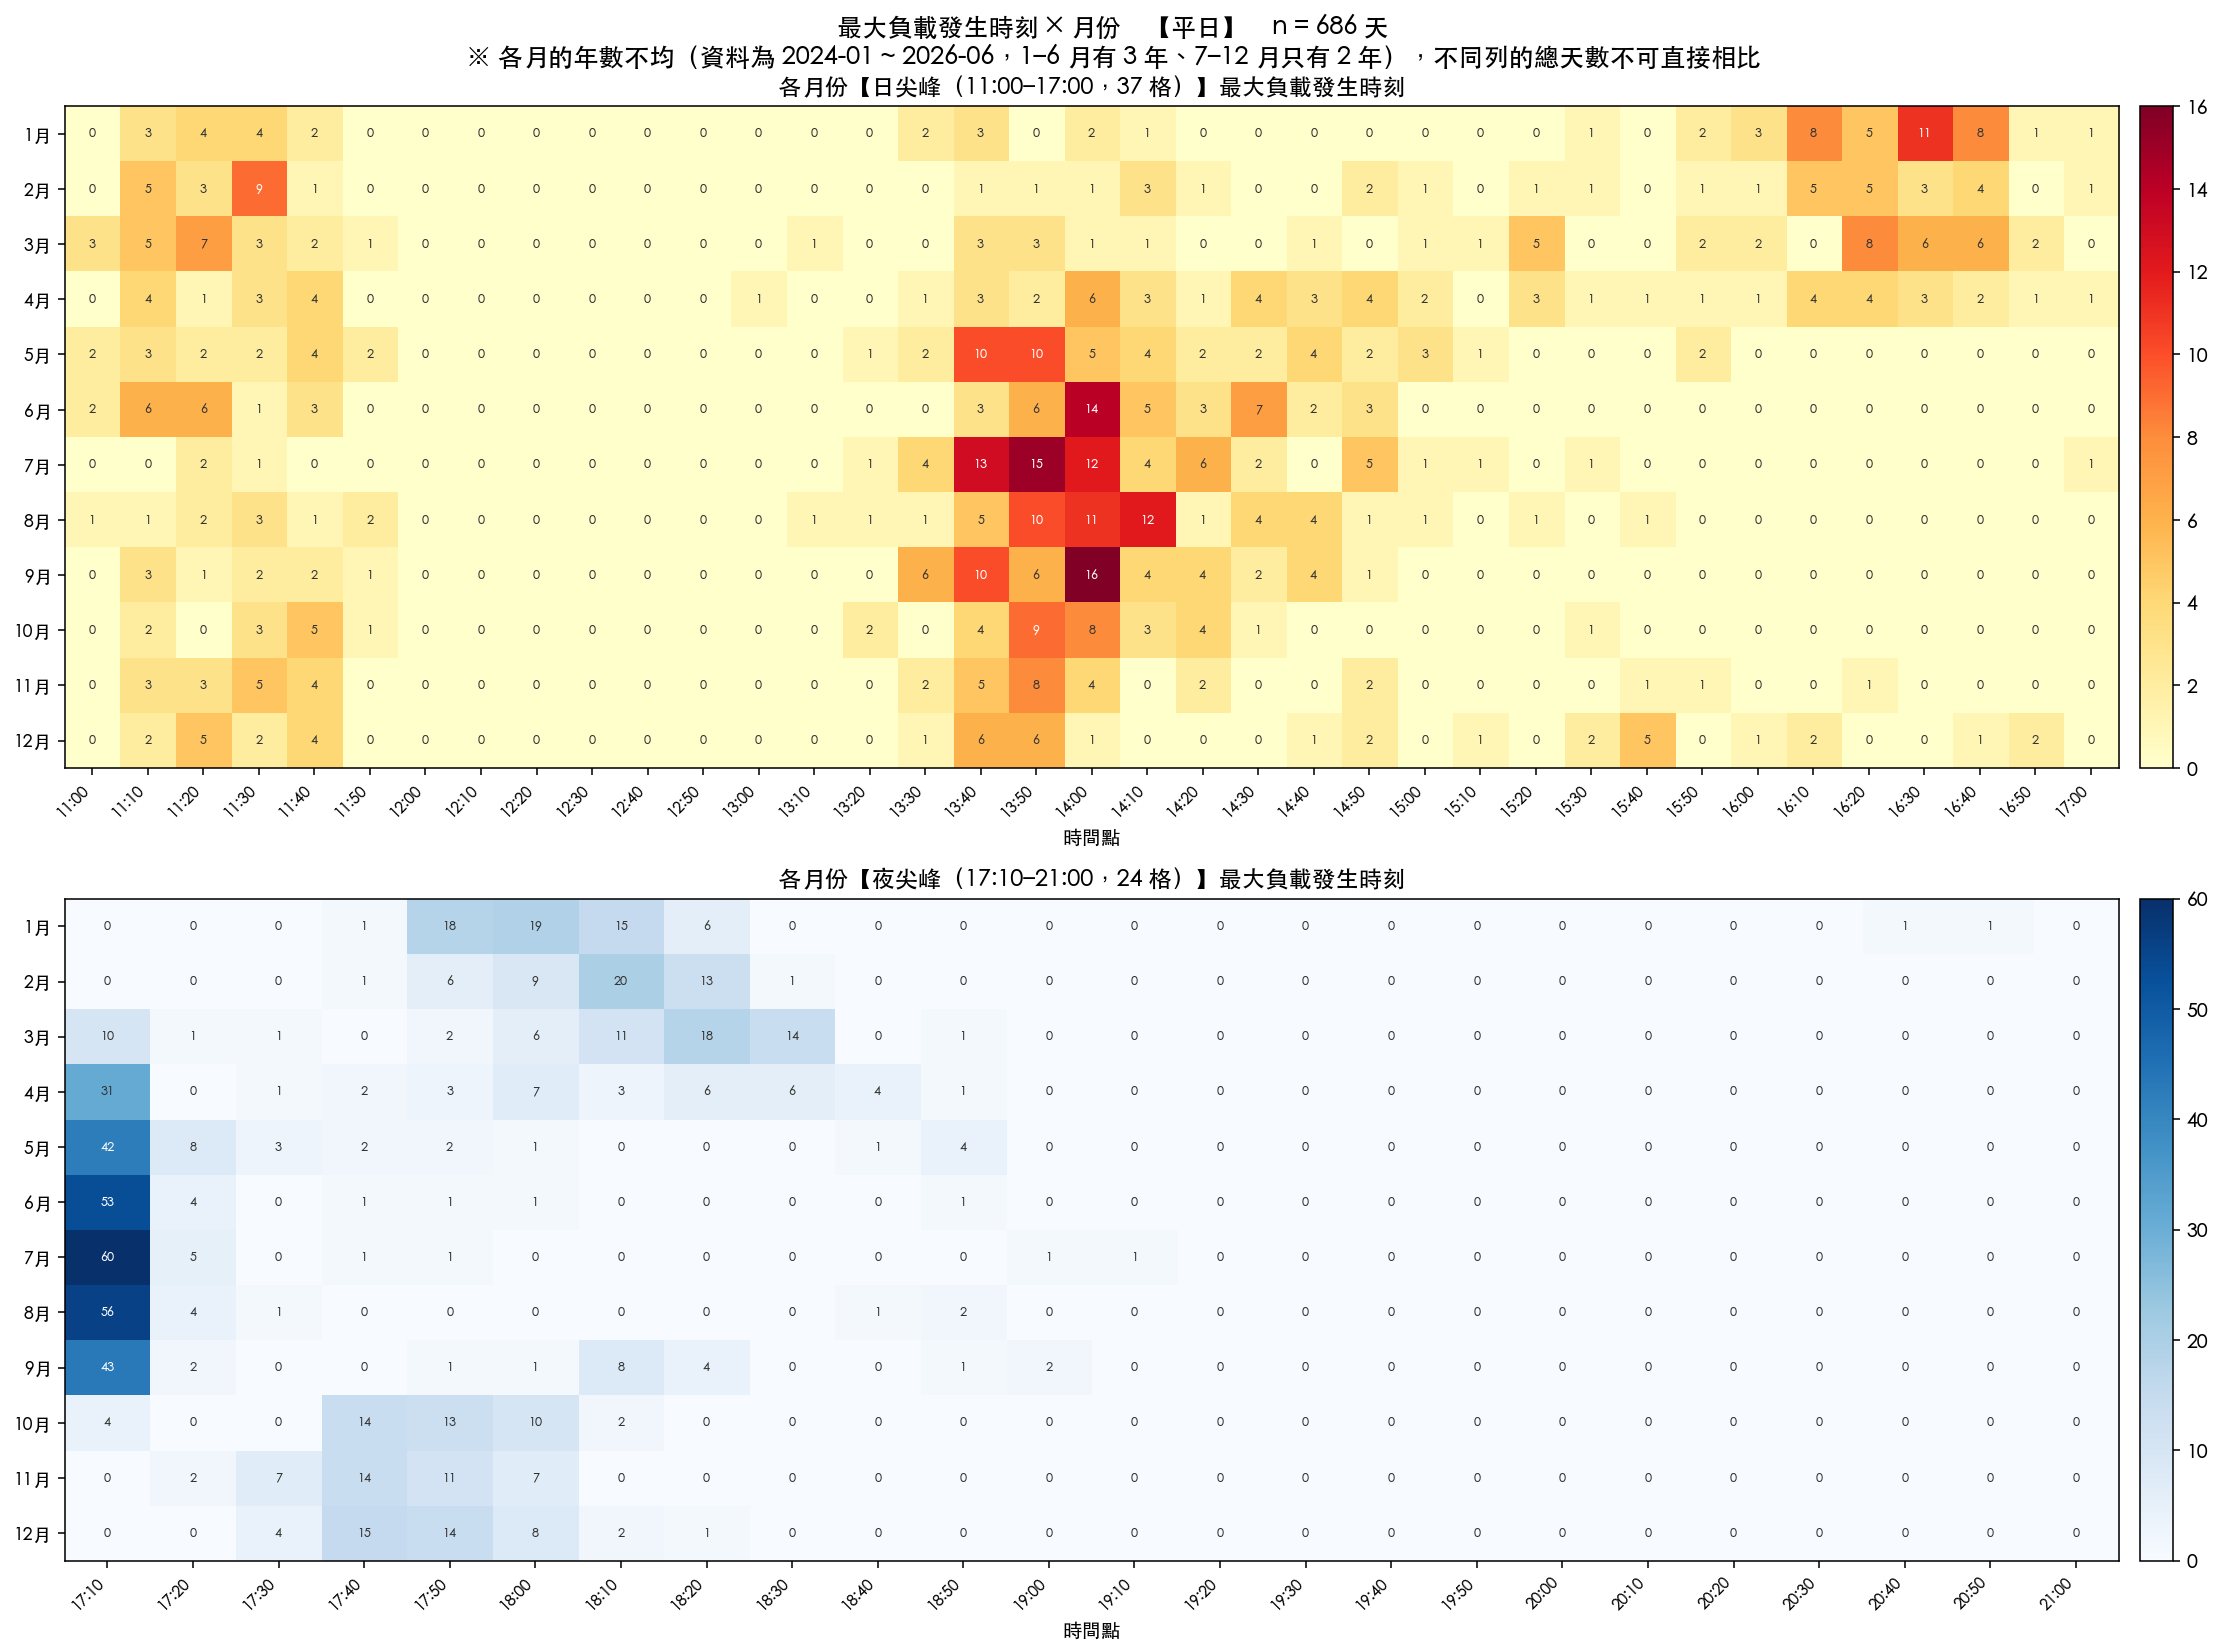

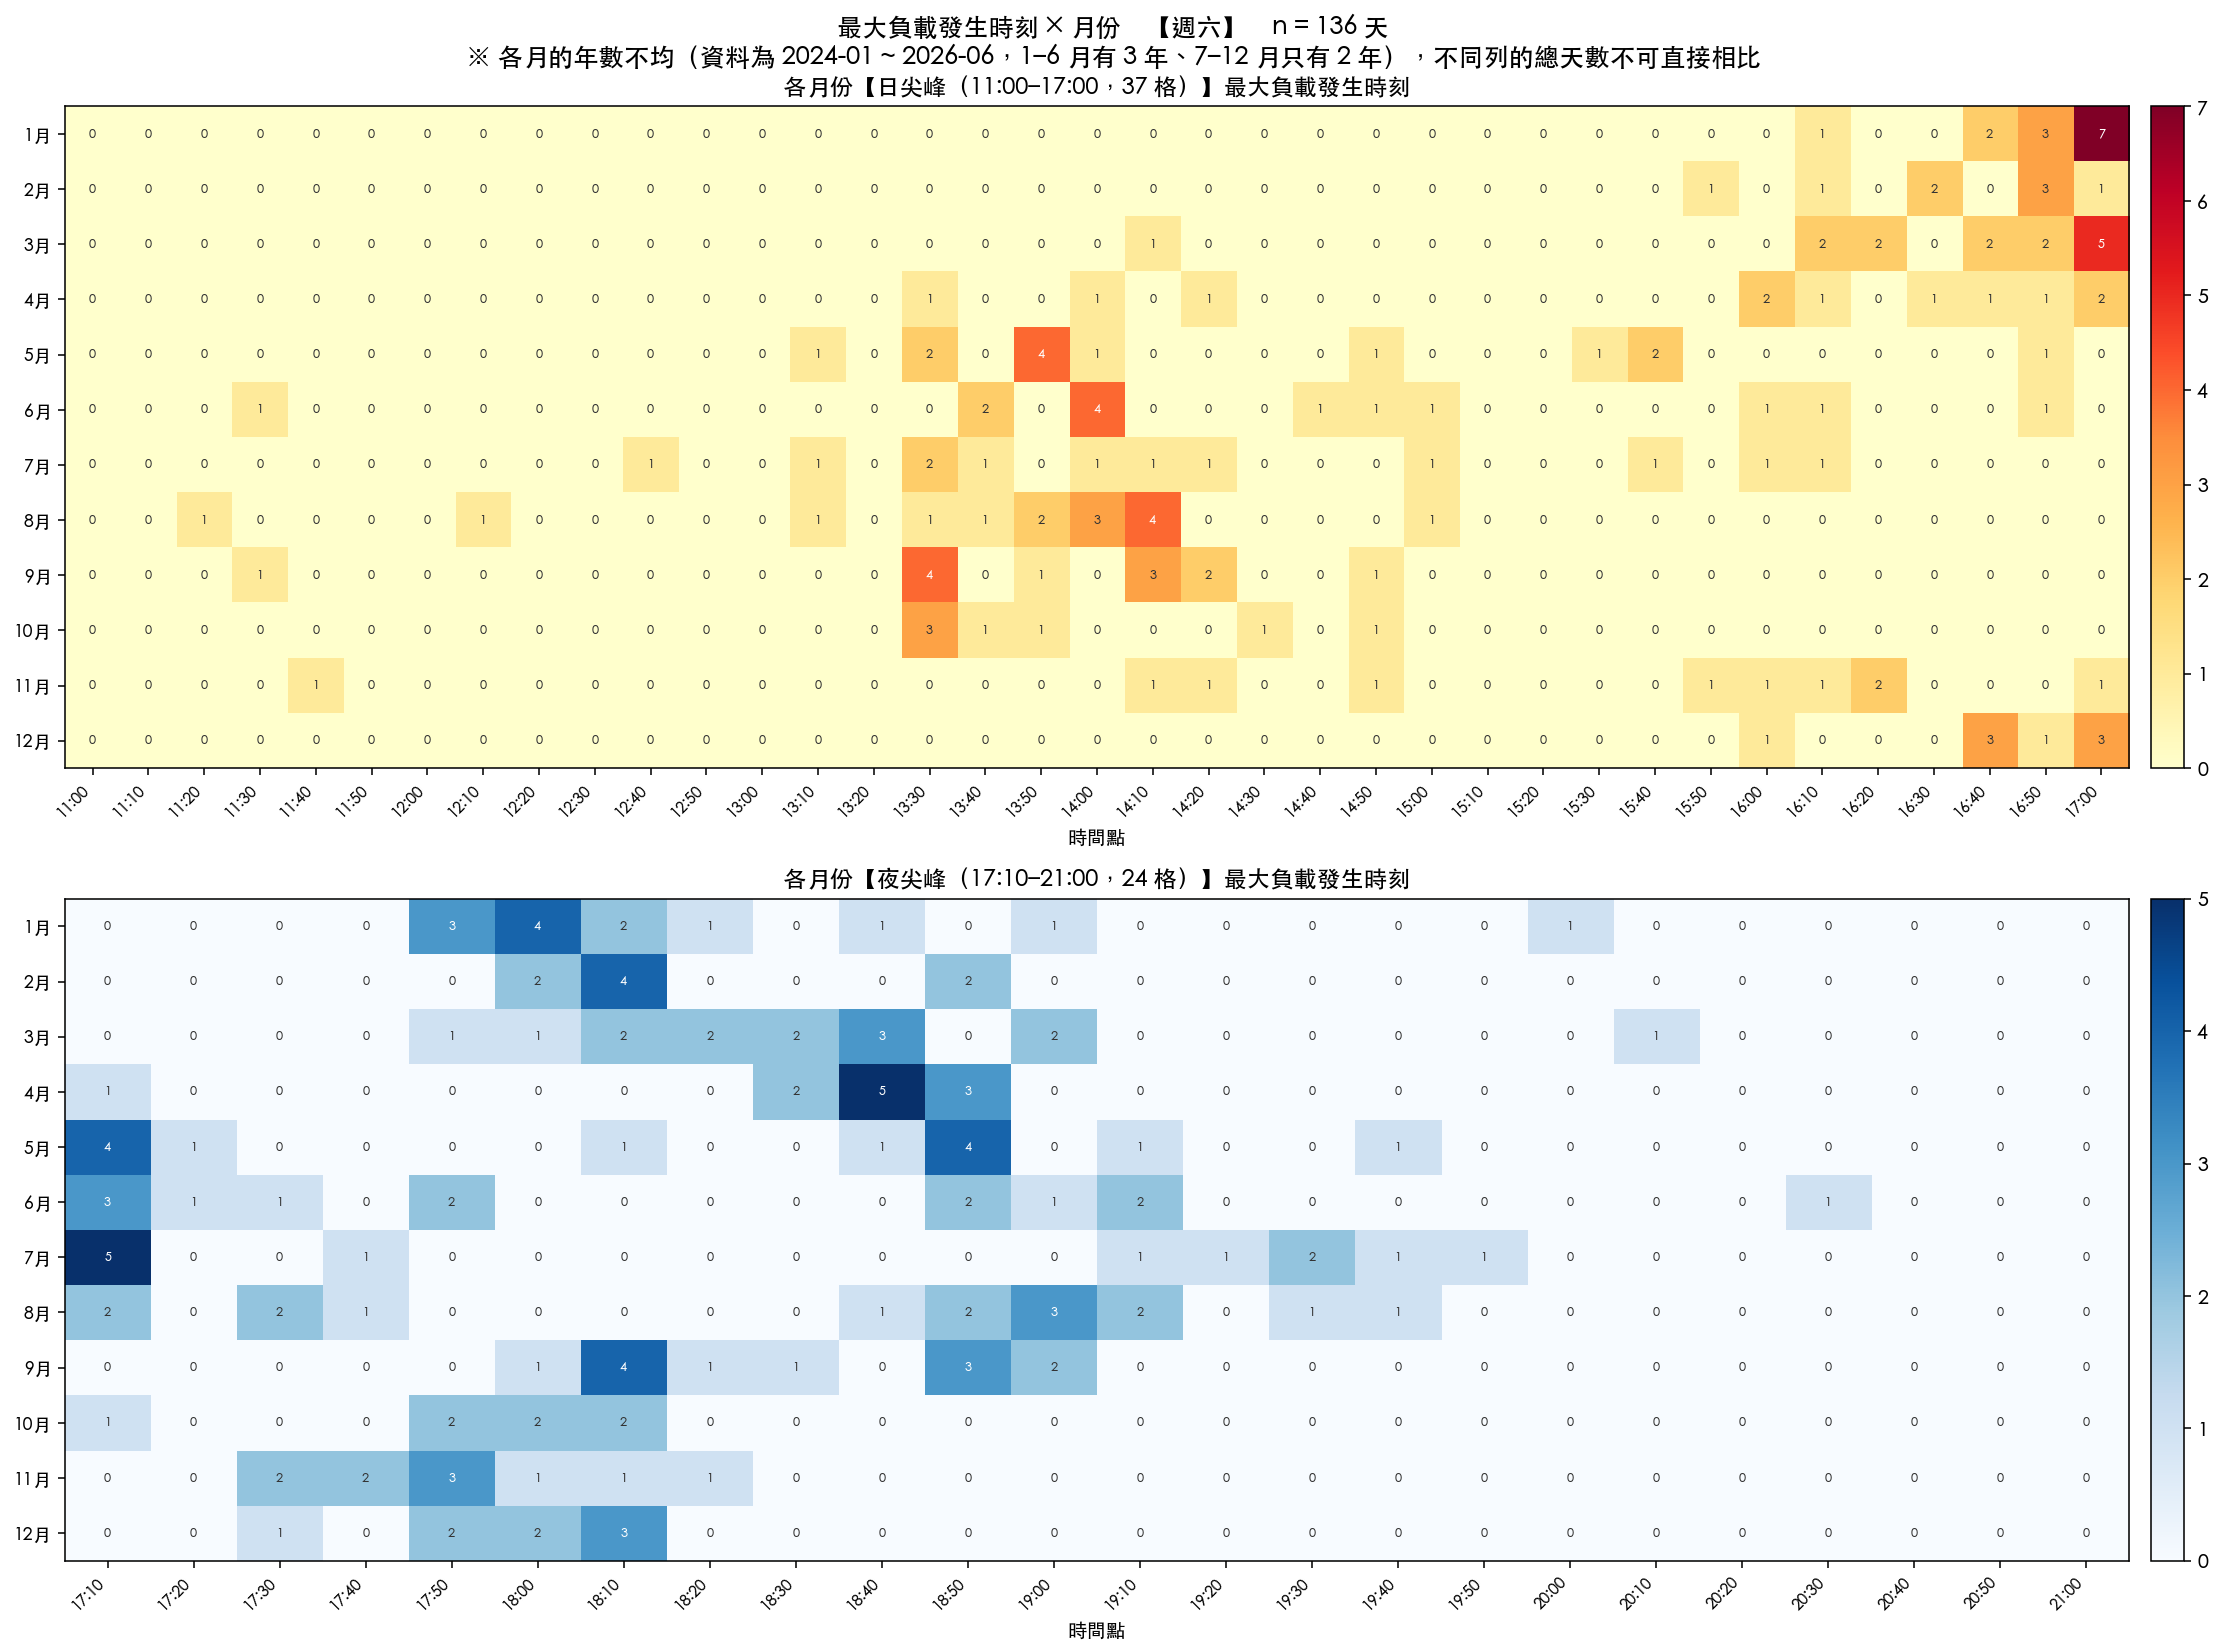

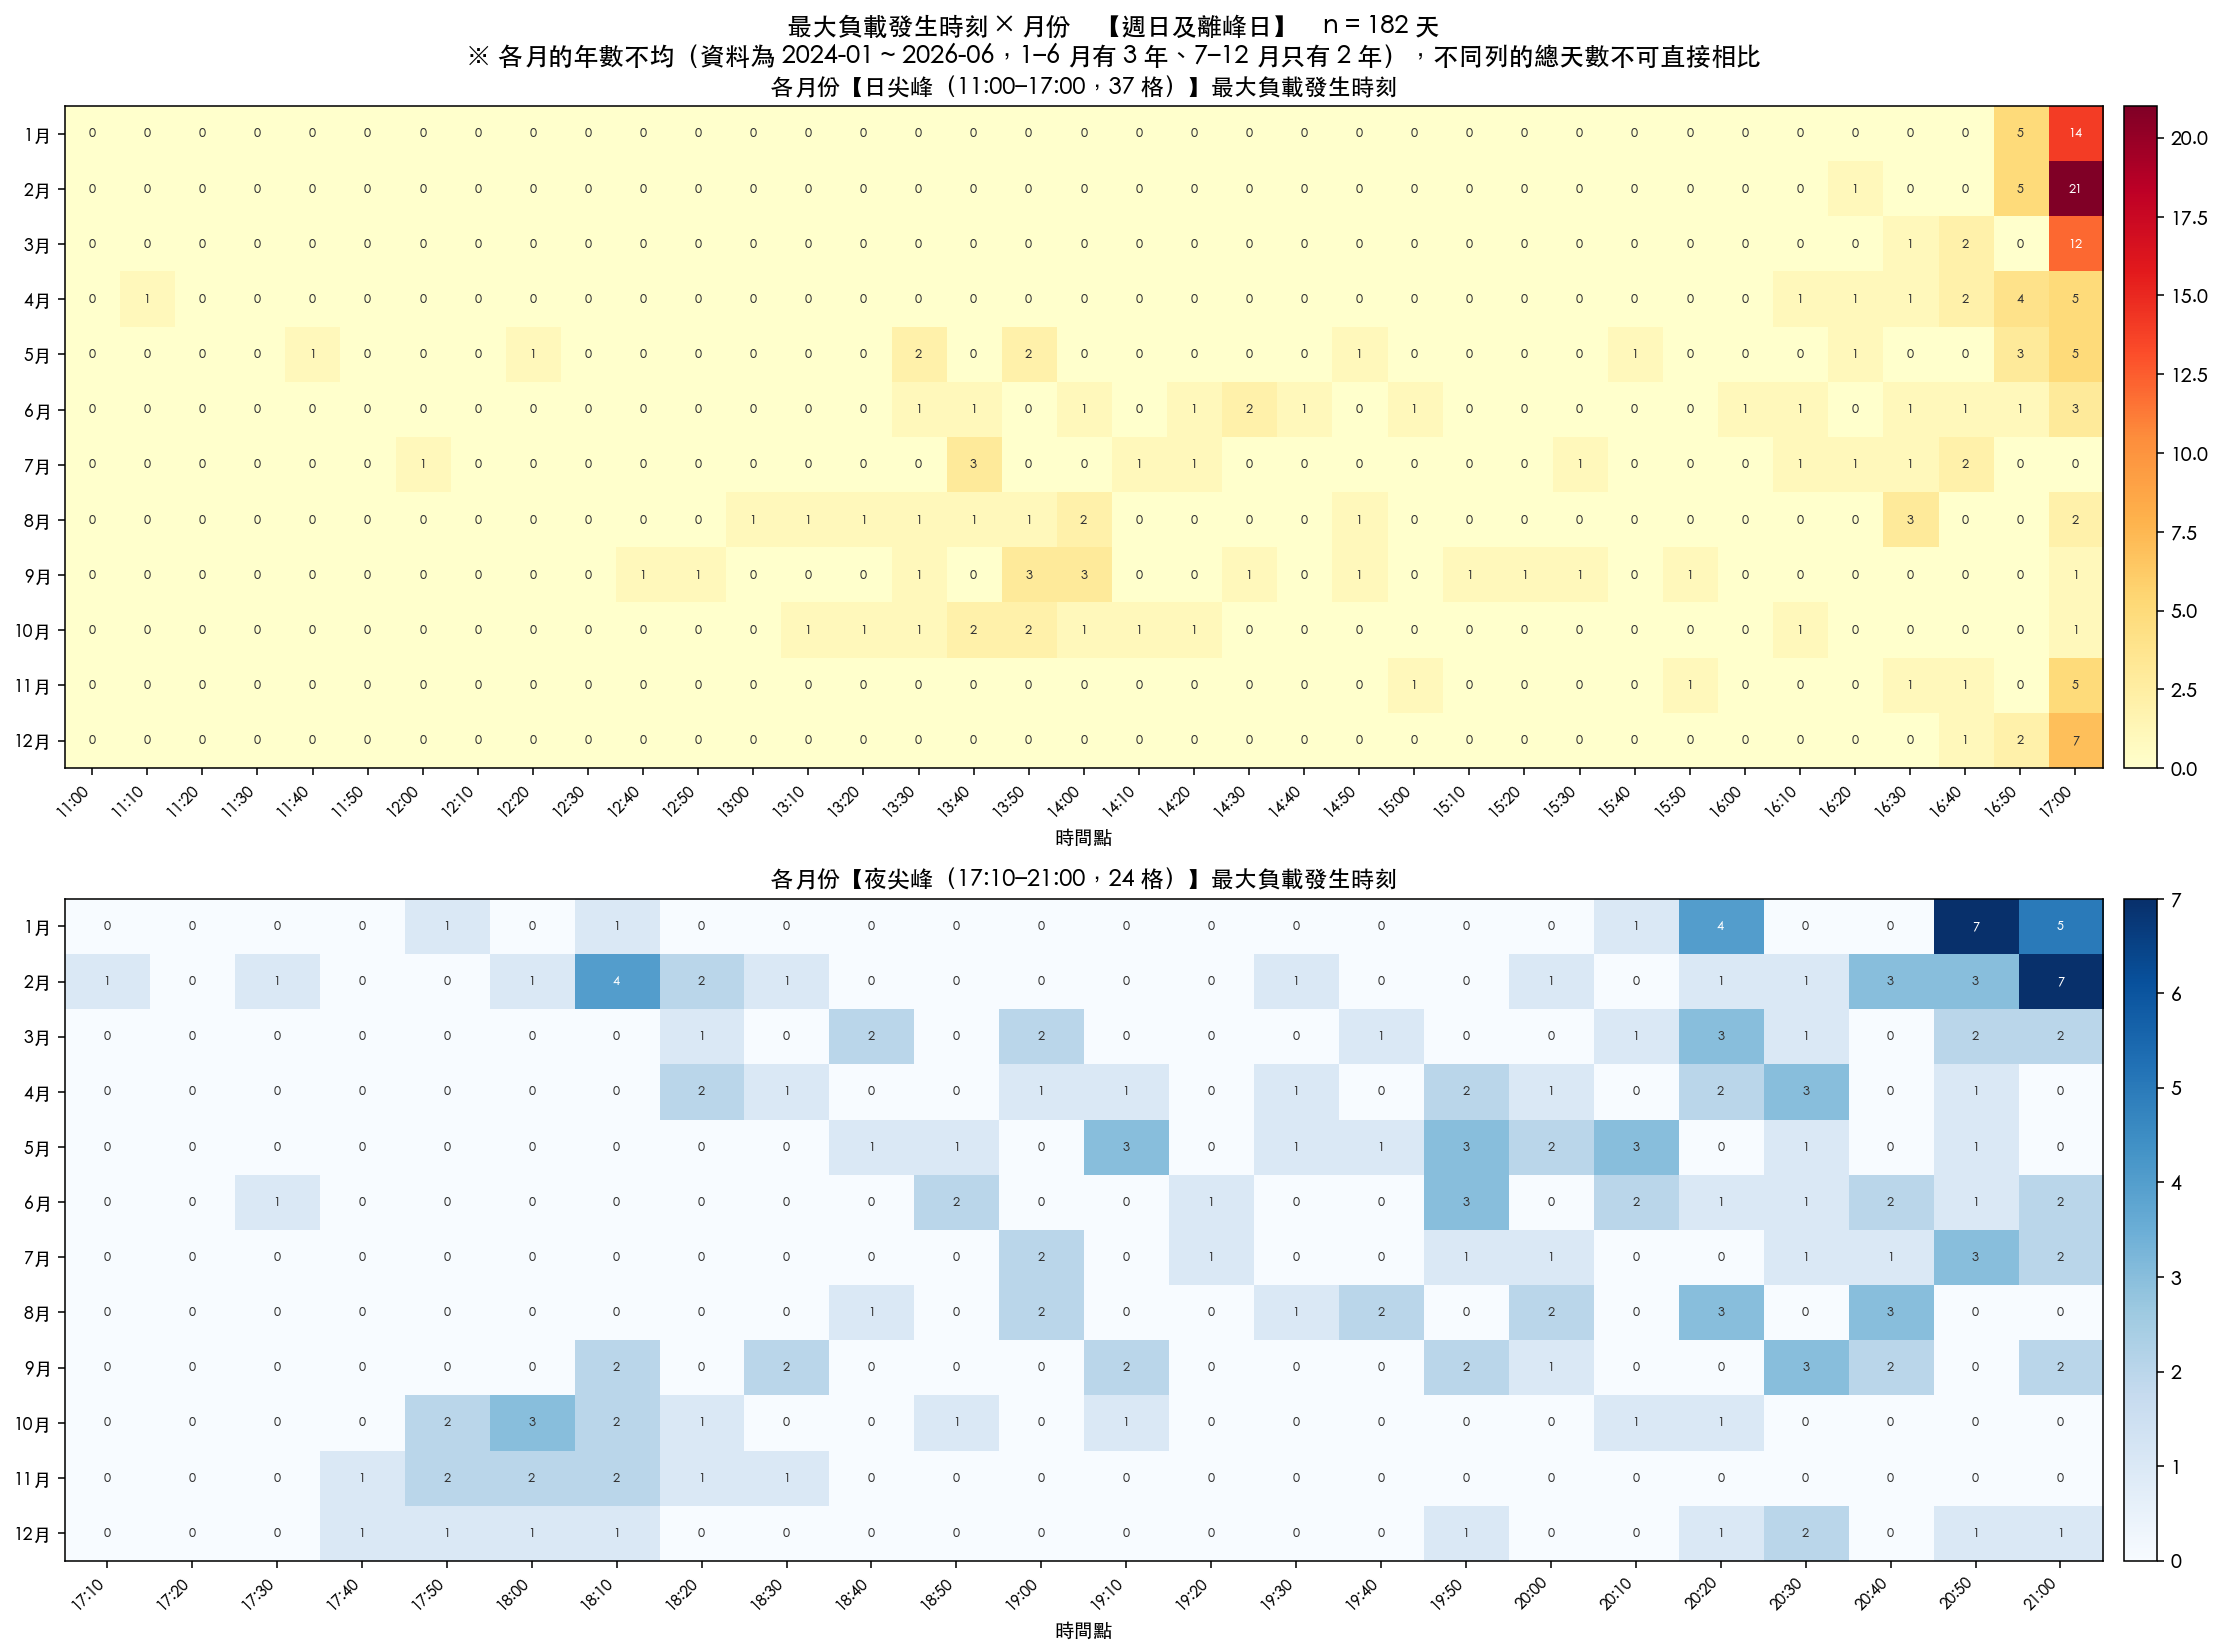

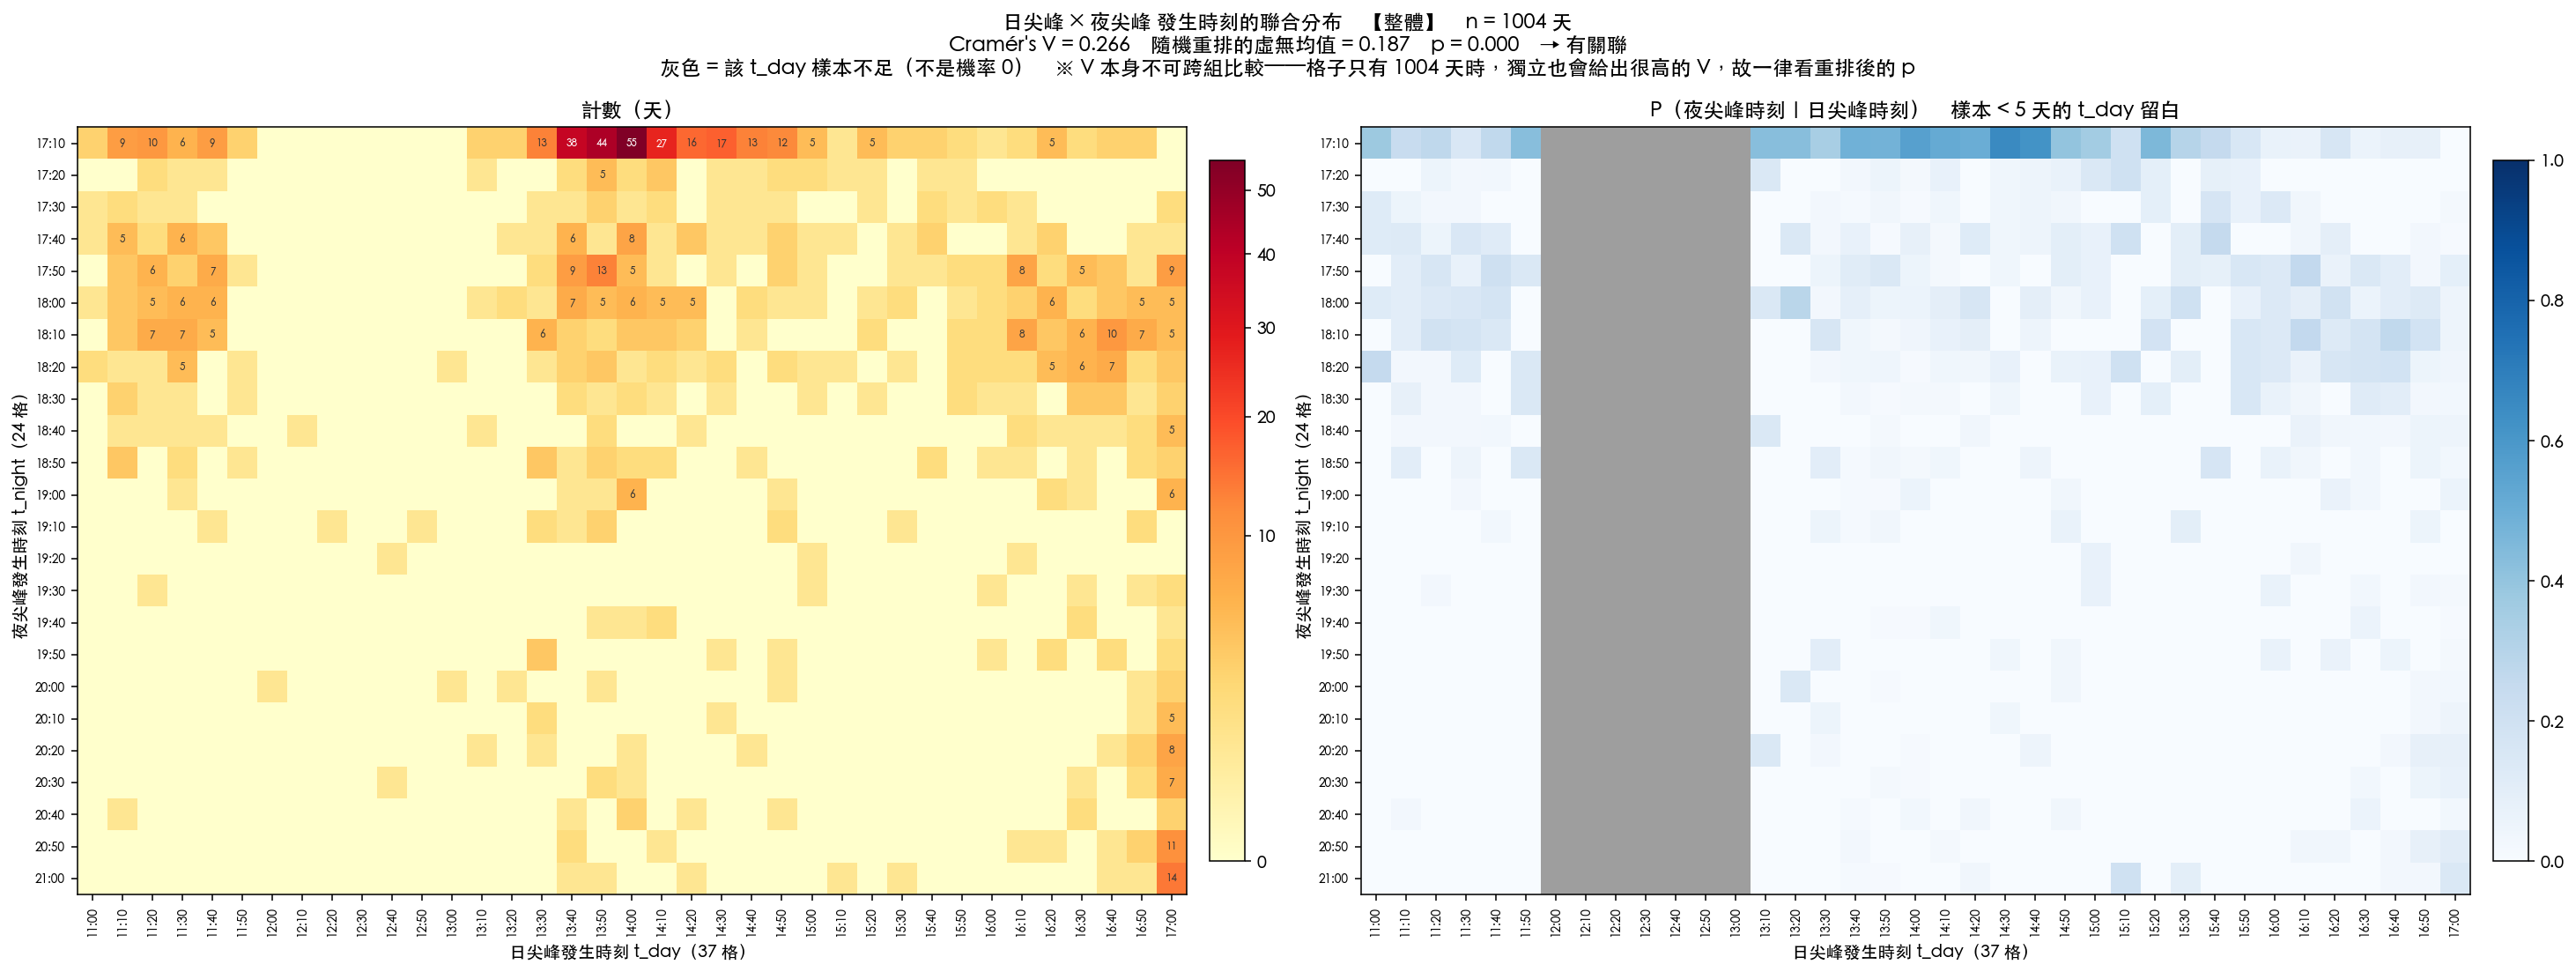

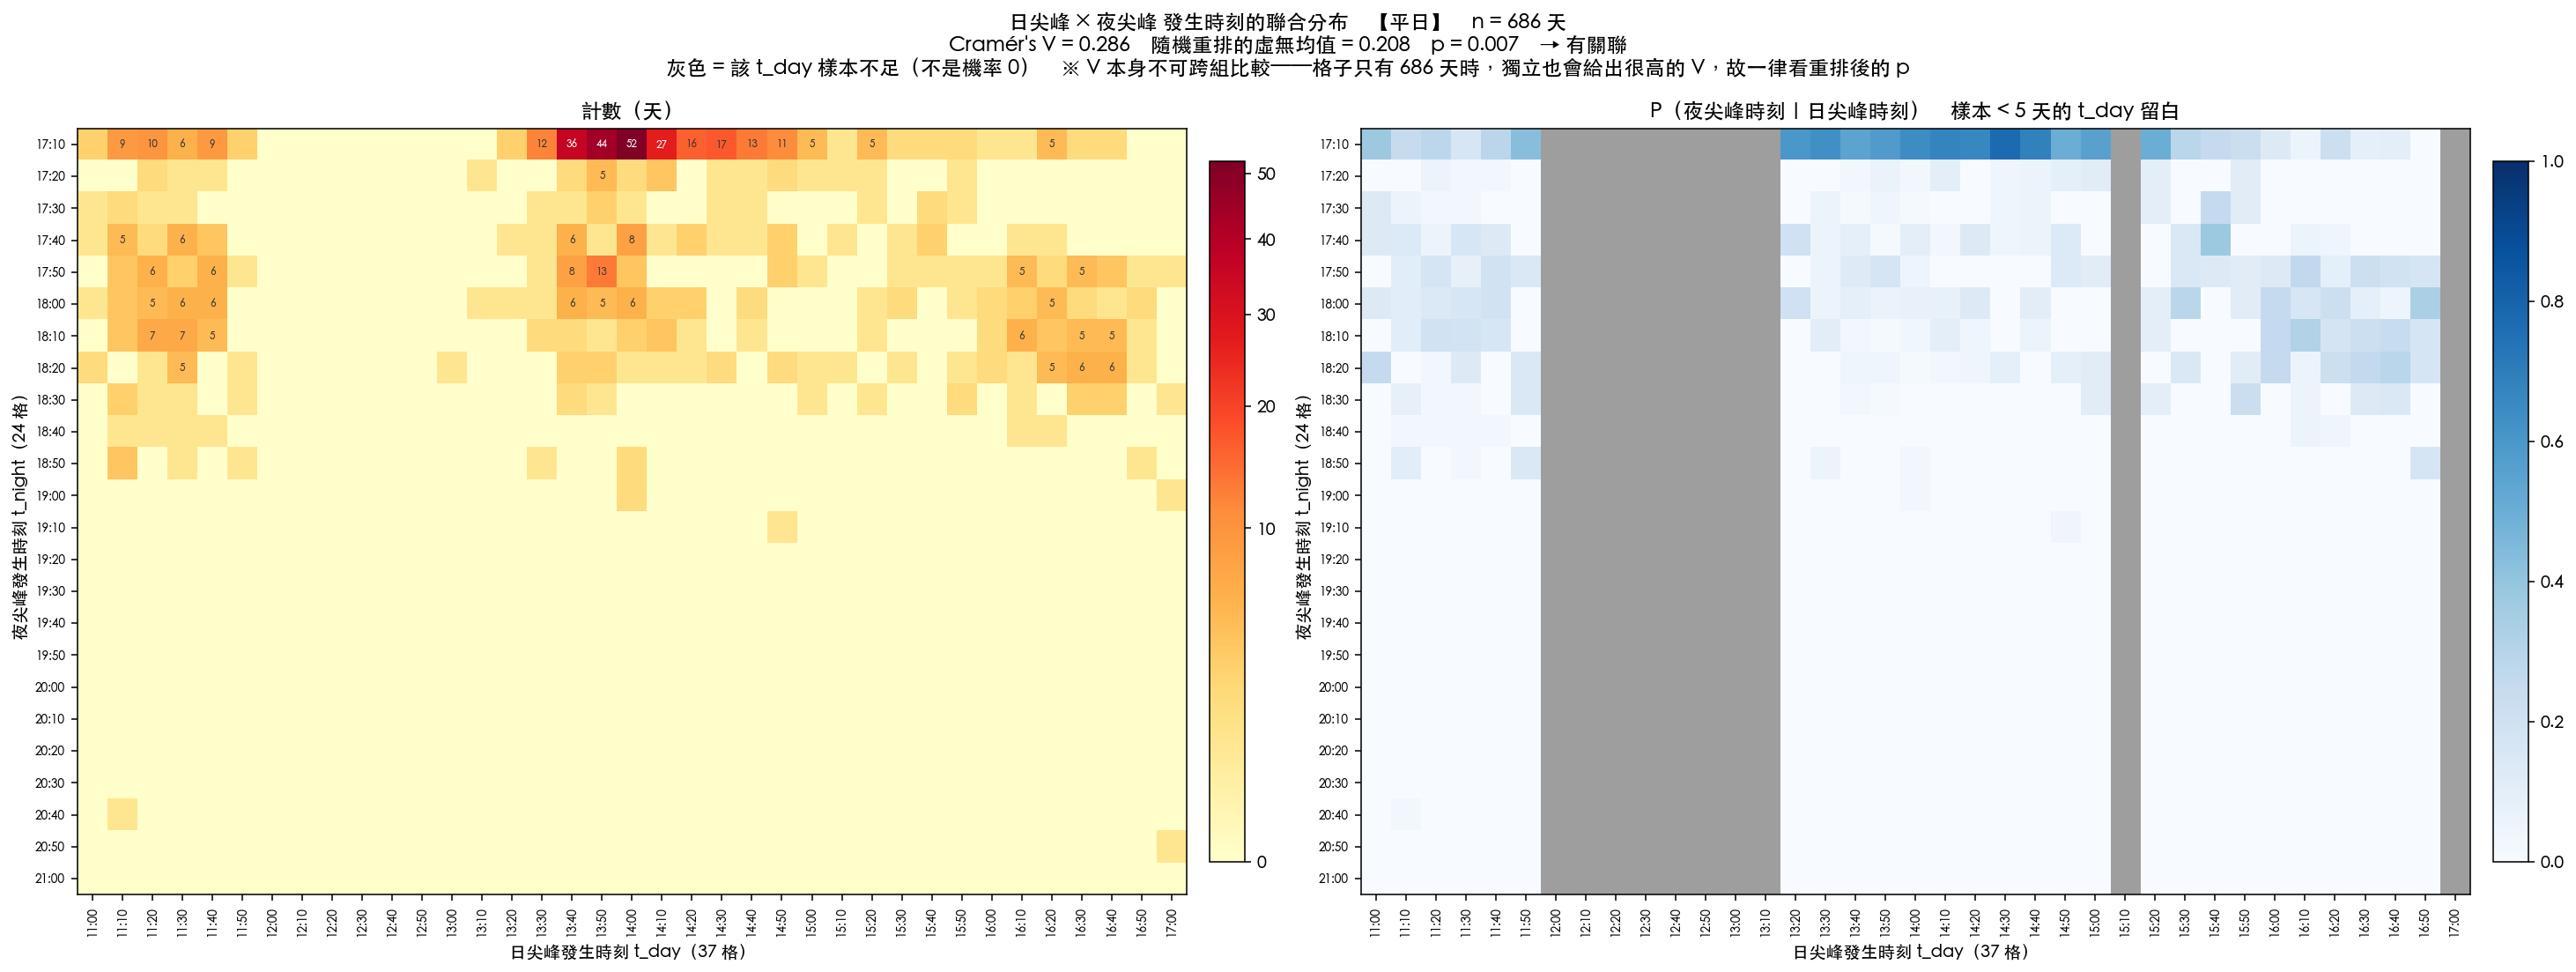

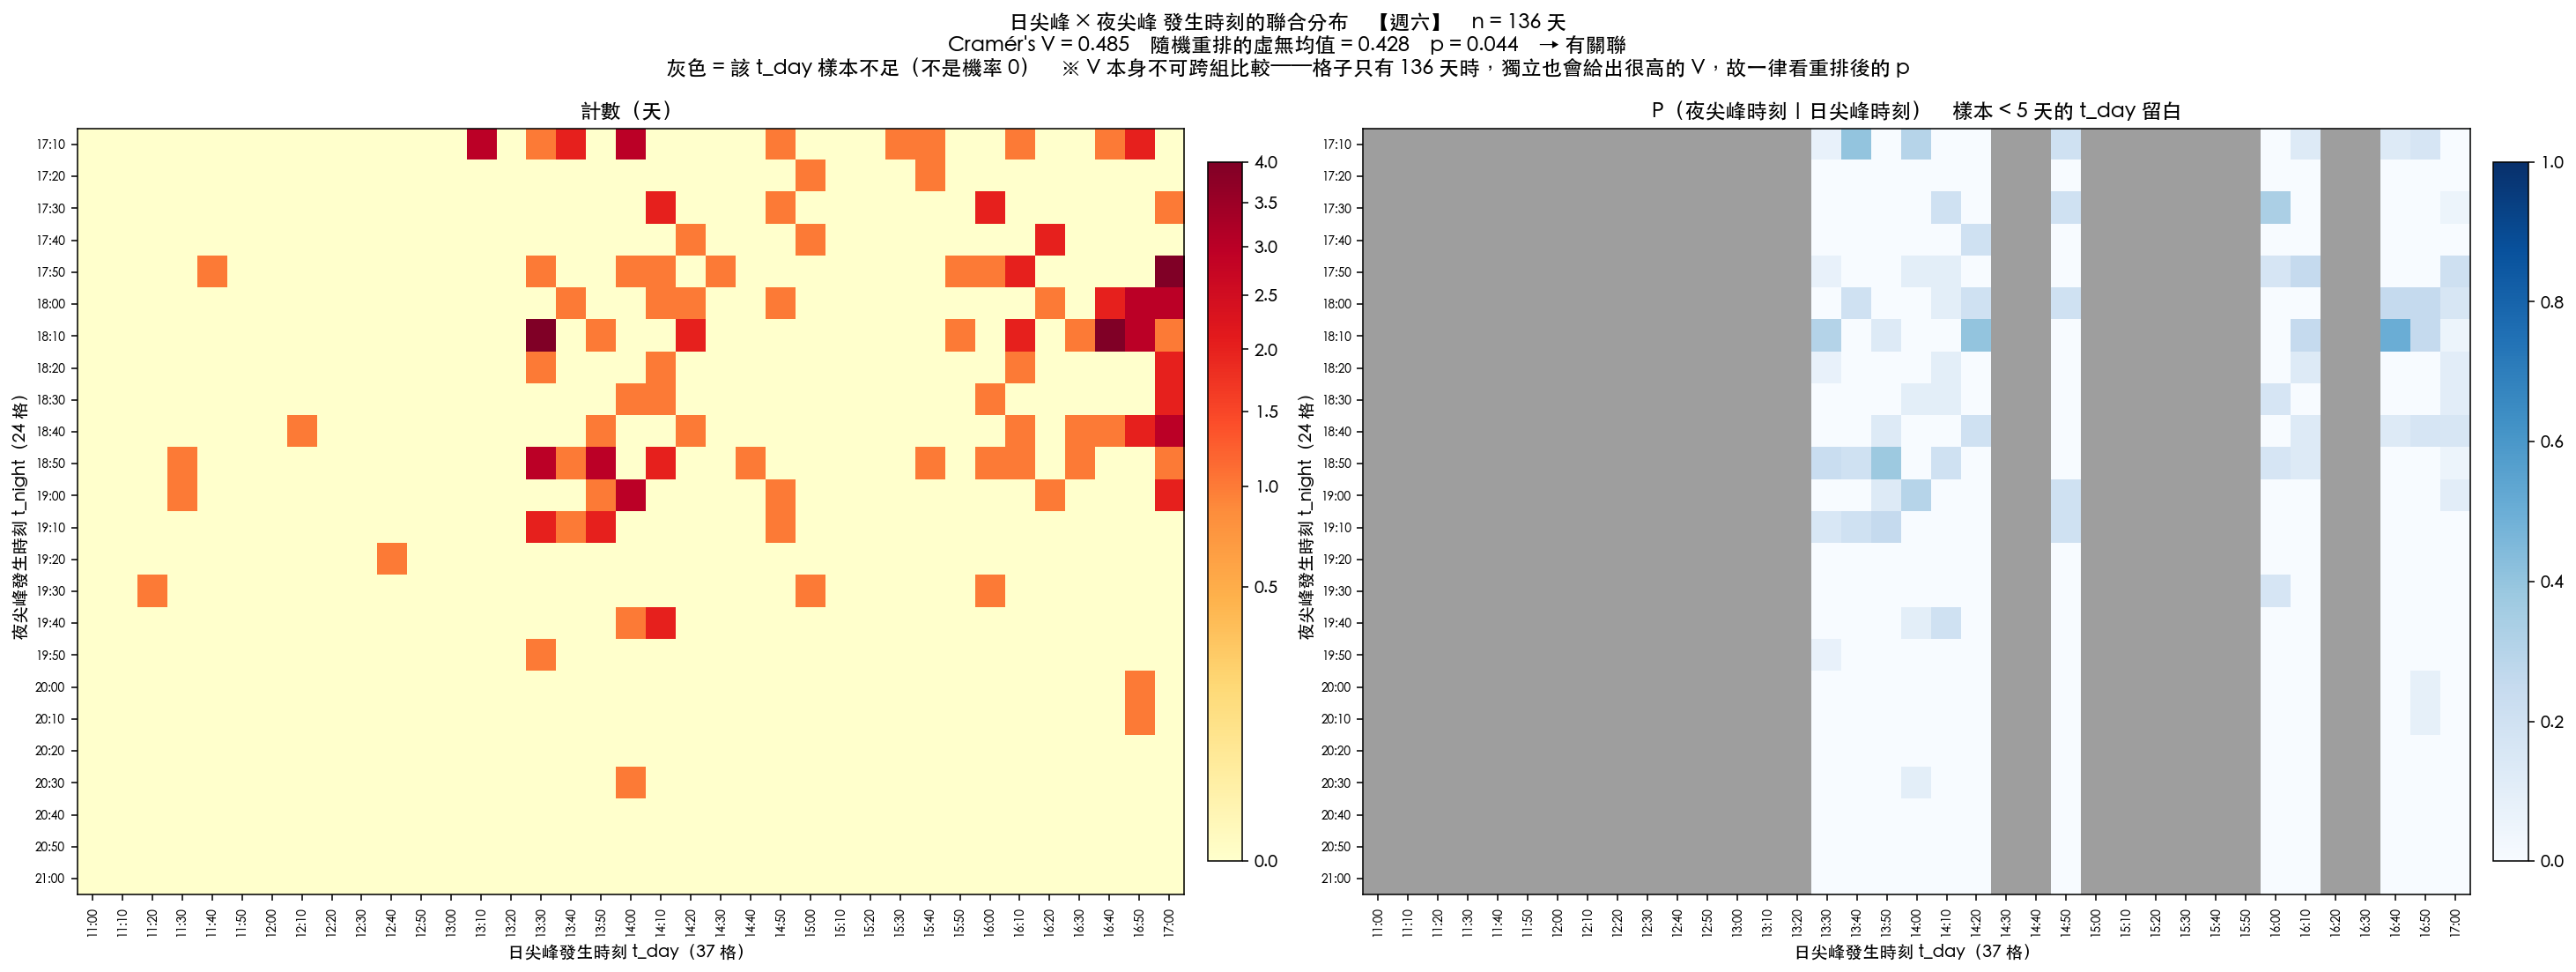

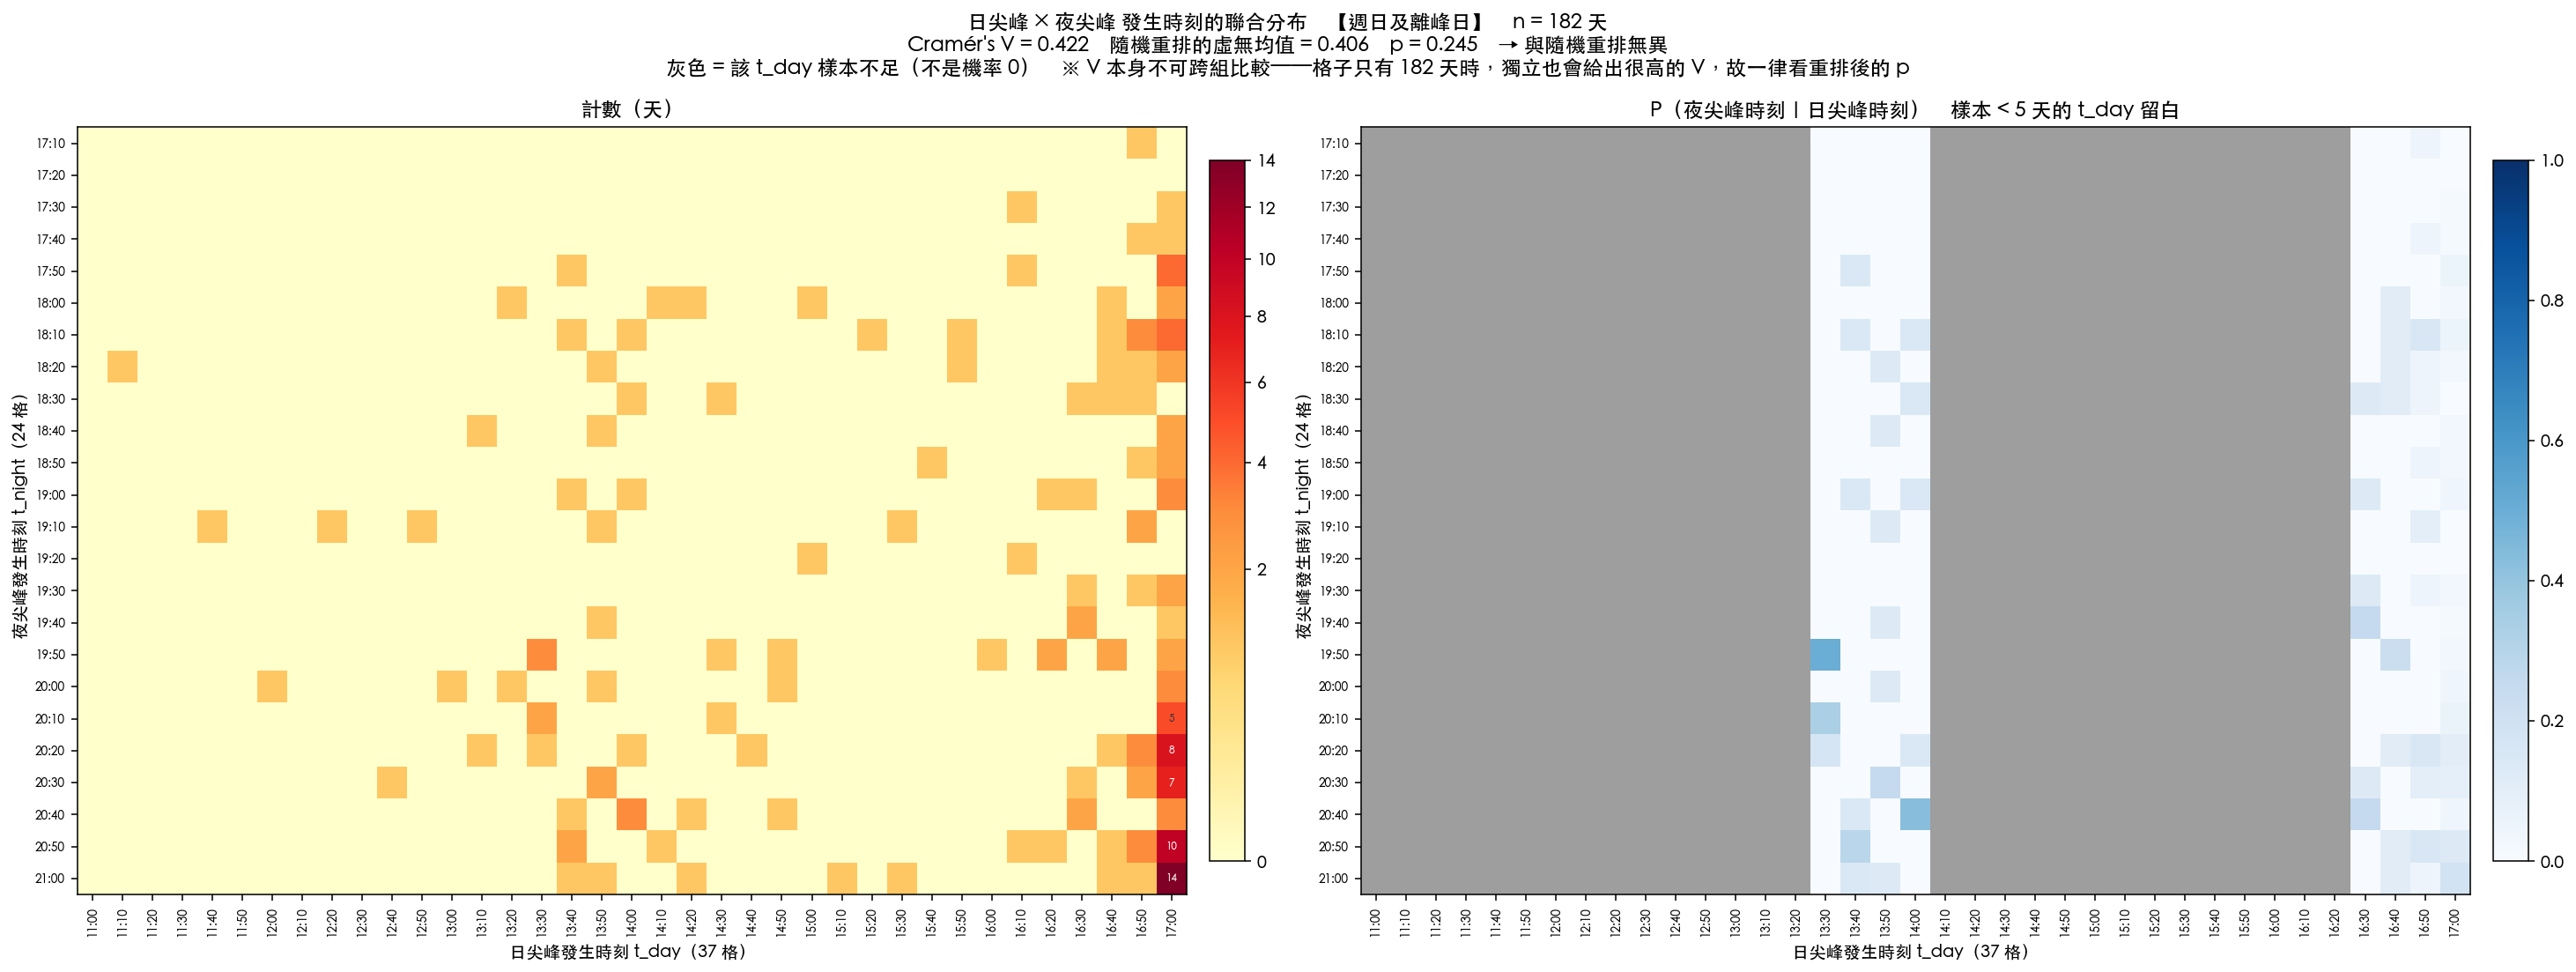

In [9]:
timing = timing_plots.load_timing()
for slug, label, daytype in timing_plots.GROUPS:
    sub = timing_plots.subset(timing, daytype)
    group = (slug, label, daytype)
    timing_plots.plot_marginal(sub, group)
    timing_plots.plot_month(sub, group)
    timing_plots.plot_joint(sub, group)
for kind in ("marginal", "month", "joint"):
    for slug, _, _ in timing_plots.GROUPS:
        display(Image(filename=str(paths.FIGURES_DIR / f"timing_{kind}_{slug}.png"), width=900))